# Phase 1: Data Understanding & Preprocessing
## Lending Club Loan Dataset

**Mining angle (arah dari dokumen penugasan).** Dokumen penugasan mengarahkan segmentasi peminjam berdasarkan profil risiko dengan tiga atribut inti: `grade` (label risiko versi Lending Club), `annual_inc` (kapasitas bayar), dan `dti` (beban utang relatif terhadap penghasilan). Ketiganya dipilih karena mewakili dimensi risiko yang berbeda dan saling melengkapi. Tiga atribut ini adalah **titik awal**, bukan daftar tertutup, subset final akan diperluas dan divalidasi melalui feature selection di Step 4 (korelasi + mutual information).

**Rule target (contoh dari dokumen penugasan).** Peminjam dengan `purpose = small_business` dan `emp_length ≥ 10 tahun` cenderung memperoleh `Grade A` dengan suku bunga rendah. Ini ilustrasi bentuk association rule yang diharapkan (Fase 3), bukan hipotesis yang wajib terbukti.

**Catatan metodologis.** `grade` merupakan penilaian risiko turunan dari Lending Club (sebagian dibentuk dari DTI, FICO, dll), sehingga bukan variabel independen murni. Penggunaannya bersama `dti` untuk clustering perlu diinterpretasikan dengan hati-hati agar tidak menimbulkan sirkularitas dalam pembacaan profil cluster.

**Dataset.** `accepted_2007_to_2018Q4.csv`, 2.260.701 baris, 151 kolom mentah.

**Alur Phase 1.** (1) Data Understanding & EDA, distribusi, missing values, tipe data, outlier. (2) Data Cleaning. (3) Data Transformation. (4) Feature Selection (korelasi + entropy). (5) Export dataset bersih + Preprocessing Report.

---
## Step 1: Exploratory Data Analysis (EDA)

Tujuan: memahami struktur data, mengukur kualitas (missing values, inkonsistensi tipe), dan mengidentifikasi distribusi serta outlier sebelum keputusan cleaning diambil.

### 1.1: Konfigurasi & Import

In [ ]:
import os
# Pindah ke root proyek agar path data konsisten di mana pun notebook dijalankan
for _ in range(6):
    if os.path.isdir('data'): break
    os.chdir('..')
print('working dir:', os.getcwd())

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid', palette='viridis')

# --- Kontrol beban data ---
# USE_FULL = True  -> muat seluruh 2,26 juta baris (jalankan di komputer lokal, butuh RAM memadai)
# USE_FULL = False -> muat sample SAMPLE_SIZE baris (untuk mesin dengan RAM terbatas)
USE_FULL   = True
SAMPLE_SIZE = 890_000
RANDOM_SEED = 42

DATA_PATH = 'data/raw/accepted_2007_to_2018Q4.csv'
print('Konfigurasi siap. USE_FULL =', USE_FULL)

Konfigurasi siap. USE_FULL = True


### 1.2: Load Data

Data dimuat penuh bila `USE_FULL=True`. Fungsi `optimize_dtypes` menurunkan presisi numerik (float64→float32, int64→downcast) untuk menekan pemakaian memori tanpa kehilangan informasi analitis.

In [146]:
def optimize_dtypes(data):
    """Downcast kolom numerik untuk menghemat memori."""
    for col in data.select_dtypes(include=['float64']).columns:
        data[col] = pd.to_numeric(data[col], downcast='float')
    for col in data.select_dtypes(include=['int64']).columns:
        data[col] = pd.to_numeric(data[col], downcast='integer')
    return data

if USE_FULL:
    df = pd.read_csv(DATA_PATH, low_memory=False)
else:
    total_rows = 2_260_701
    rng = np.random.RandomState(RANDOM_SEED)
    skip = sorted(rng.choice(np.arange(1, total_rows + 1),
                             size=total_rows - SAMPLE_SIZE, replace=False))
    df = pd.read_csv(DATA_PATH, low_memory=False, skiprows=skip)

df = optimize_dtypes(df)

print(f'Baris  : {df.shape[0]:,}')
print(f'Kolom  : {df.shape[1]}')
print(f'Memori : {df.memory_usage(deep=True).sum()/1e9:.2f} GB')
df.head(3)

Baris  : 2,260,701
Kolom  : 151
Memori : 5.38 GB


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.029999,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.280029,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.660004,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3: Struktur & Tipe Data

Memetakan komposisi tipe kolom dan statistik deskriptif fitur numerik. Kolom persen (`int_rate`, `revol_util`) tersimpan sebagai string dan dikonversi ke numerik di sini (permanen; konversi ini benar secara data dan menghindari salinan memori pada dataset penuh).

In [147]:
print('=== KOMPOSISI TIPE DATA ===')
for dtype, count in df.dtypes.astype(str).value_counts().items():
    print(f'  {dtype:12s}: {count} kolom')
print(f'\nTotal kolom: {df.shape[1]}')

# Konversi kolom persen ke numerik. int_rate & revol_util tersimpan sebagai string ('13.56%').
# Dilakukan PERMANEN di df: konversi ini benar secara data, dan menghindari duplikasi memori
# akibat df.copy() pada dataset penuh. (Guard di Step 2 otomatis melewati kolom yang sudah numerik.)
for c in ['int_rate', 'revol_util']:
    if c in df.columns and df[c].dtype == 'object':
        df[c] = pd.to_numeric(df[c].astype(str).str.replace('%', '', regex=False), errors='coerce')

# df_eda = alias df (BUKAN copy) → sel-sel berikut tetap konsisten, tanpa menggandakan RAM.
df_eda = df
print('Konversi int_rate & revol_util → numerik selesai. df_eda = alias df (tanpa copy).')

=== KOMPOSISI TIPE DATA ===
  float32     : 100 kolom
  object      : 38 kolom
  float64     : 13 kolom

Total kolom: 151
Konversi int_rate & revol_util → numerik selesai. df_eda = alias df (tanpa copy).


In [148]:
print('=== STATISTIK DESKRIPTIF (fitur numerik) ===')
df_eda.describe().T

=== STATISTIK DESKRIPTIF (fitur numerik) ===


,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.929688,9190.246094,500.00,8000.000000,12900.000000,20000.000000,40000.000000
funded_amnt,2260668.0,15041.665039,9188.413086,500.00,8000.000000,12875.000000,20000.000000,40000.000000
funded_amnt_inv,2260668.0,15023.437745,9192.331679,0.00,8000.000000,12800.000000,20000.000000,40000.000000
int_rate,2260668.0,13.092829,4.832139,5.31,9.490000,12.620000,15.990000,30.990000
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10917.0,11636.883942,7625.988281,55.73,5627.000000,10028.390000,16151.890000,40306.410000
hardship_last_payment_amount,10917.0,193.994324,198.629501,0.01,44.439999,133.160004,284.190002,1407.859985
settlement_amount,34246.0,5010.664267,3693.122590,44.21,2208.000000,4146.110000,6850.172500,33601.000000
settlement_percentage,34246.0,47.780346,7.311822,0.20,45.000000,45.000000,50.000000,521.349976


### 1.4: Analisis Missing Values

Kolom dikelompokkan berdasarkan proporsi nilai kosong: >50%, 20–50%, dan <20%. Namun proporsi tinggi **tidak** langsung berarti drop, pada Lending Club banyak missing bersifat *structural* (missing by design). Karena itu tiap kolom diberi dugaan mekanisme (structural / leakage / MAR temporal / opsional), lalu diverifikasi di 1.4b sebelum keputusan cleaning diambil di Step 2.

In [149]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = (pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
              .query('`Missing Count` > 0')
              .sort_values('Missing %', ascending=False))

# Klasifikasi heuristik mekanisme missing berdasarkan skema Lending Club.
# Tujuan: JANGAN drop hanya karena >50% missing. Telaah mekanismenya dulu.
def klasifikasi_missing(col):
    c = col.lower()
    if c in {'id', 'member_id', 'url'}:
        return 'IDENTIFIER — bukan fitur, drop di Step 2'
    if 'joint' in c or c.startswith('sec_app_'):
        return 'STRUCTURAL — hanya terisi untuk Joint App (MAR, driver: application_type)'
    if c.startswith('mths_since'):
        return 'STRUCTURAL — NaN = event tidak pernah terjadi (kandidat flag + sentinel)'
    if c.startswith('hardship_') or c.startswith('settlement_') or 'debt_settlement' in c:
        return 'POST-LOAN LEAKAGE — drop (alasan leakage, bukan missing)'
    if c == 'desc':
        return 'OPSIONAL — teks bebas, kosong = tidak diisi'
    if any(k in c for k in ['_il', 'il_', 'open_acc_6m', 'all_util', 'inq_last_12m',
                            'open_rv', 'max_bal_bc', 'total_cu_tl', 'inq_fi']):
        return 'MAR TEMPORAL — hanya terisi periode/aplikasi tertentu'
    return 'PERLU DITELAAH — mekanisme belum jelas'

missing_df['Mekanisme (dugaan)'] = missing_df.index.map(klasifikasi_missing)

print('=== RINGKASAN MISSING VALUES ===')
print(f'  Kolom tanpa missing        : {df.shape[1] - len(missing_df)}')
print(f'  Kolom dengan missing       : {len(missing_df)}')
print(f'   >50% (PERLU DITELAAH)     : {(missing_df["Missing %"] > 50).sum()}')
print(f'   20-50% (EVALUASI)         : {((missing_df["Missing %"] > 20) & (missing_df["Missing %"] <= 50)).sum()}')
print(f'   <20%  (kandidat IMPUTE)   : {(missing_df["Missing %"] <= 20).sum()}')
print('\nDistribusi mekanisme (dugaan):')
print(missing_df['Mekanisme (dugaan)'].str.split(' —').str[0].value_counts())
missing_df

=== RINGKASAN MISSING VALUES ===
  Kolom tanpa missing        : 1
  Kolom dengan missing       : 150
   >50% (PERLU DITELAAH)     : 44
   20-50% (EVALUASI)         : 14
   <20%  (kandidat IMPUTE)   : 92

Distribusi mekanisme (dugaan):
Mekanisme (dugaan)
PERLU DITELAAH       88
STRUCTURAL           24
POST-LOAN LEAKAGE    19
MAR TEMPORAL         16
IDENTIFIER            2
OPSIONAL              1
Name: count, dtype: int64


,Missing Count,Missing %,Mekanisme (dugaan)
member_id,2260701,100.00,"IDENTIFIER — bukan fitur, drop di Step 2"
orig_projected_additional_accrued_interest,2252050,99.62,PERLU DITELAAH — mekanisme belum jelas
hardship_payoff_balance_amount,2249784,99.52,"POST-LOAN LEAKAGE — drop (alasan leakage, buka..."
hardship_last_payment_amount,2249784,99.52,"POST-LOAN LEAKAGE — drop (alasan leakage, buka..."
payment_plan_start_date,2249784,99.52,PERLU DITELAAH — mekanisme belum jelas
...,...,...,...
total_rec_int,33,0.00,PERLU DITELAAH — mekanisme belum jelas
earliest_cr_line,62,0.00,PERLU DITELAAH — mekanisme belum jelas
hardship_flag,33,0.00,"POST-LOAN LEAKAGE — drop (alasan leakage, buka..."
disbursement_method,33,0.00,PERLU DITELAAH — mekanisme belum jelas


### 1.4b: Verifikasi Mekanisme Missing (Structural vs Acak)

Sebelum memutuskan drop/impute, klasifikasi dugaan pada 1.4 diverifikasi terhadap data. Missing yang *structural* (missing by design) memiliki driver yang dapat ditunjukkan: kolom `*_joint` mestinya kosong tepat saat aplikasi bukan Joint App, dan `mths_since_last_delinq` kosong tepat saat peminjam tak punya riwayat delinquency. Bila terbukti structural, kolom tidak di-drop buta, melainkan ditangani via flag biner + sentinel (Step 2).

In [150]:
# Uji 1: apakah missing kolom joint dijelaskan penuh oleh application_type?
if 'application_type' in df.columns:
    joint_cols = [c for c in df.columns if 'joint' in c.lower()]
    is_individual = df['application_type'].astype(str).str.contains('Individual')
    print('Verifikasi structural missingness — kolom JOINT:')
    print('-' * 72)
    for c in joint_cols:
        m_ind = df.loc[is_individual, c].isnull().mean() * 100
        m_joint = df.loc[~is_individual, c].isnull().mean() * 100
        print(f'  {c:26s} | missing saat Individual: {m_ind:5.1f}%  | saat Joint: {m_joint:5.1f}%')
    print('  -> ~100% saat Individual & rendah saat Joint = STRUCTURAL (missing by design).')

# Uji 2: mths_since_last_delinq kosong tepat saat tak ada delinquency 2 tahun?
if {'mths_since_last_delinq', 'delinq_2yrs'}.issubset(df.columns):
    tanpa_delinq = df['delinq_2yrs'].fillna(0) == 0
    p = df.loc[tanpa_delinq, 'mths_since_last_delinq'].isnull().mean() * 100
    print(f'\nmths_since_last_delinq — missing pada peminjam tanpa delinquency 2th: {p:.1f}%')
    print('  -> Tinggi = STRUCTURAL: NaN berarti "belum pernah delinquent", bukan data hilang acak.')

Verifikasi structural missingness — kolom JOINT:
------------------------------------------------------------------------
  annual_inc_joint           | missing saat Individual: 100.0%  | saat Joint:   0.0%
  dti_joint                  | missing saat Individual: 100.0%  | saat Joint:   0.0%
  verification_status_joint  | missing saat Individual: 100.0%  | saat Joint:   4.2%
  revol_bal_joint            | missing saat Individual: 100.0%  | saat Joint:  10.5%
  -> ~100% saat Individual & rendah saat Joint = STRUCTURAL (missing by design).

mths_since_last_delinq — missing pada peminjam tanpa delinquency 2th: 62.7%
  -> Tinggi = STRUCTURAL: NaN berarti "belum pernah delinquent", bukan data hilang acak.


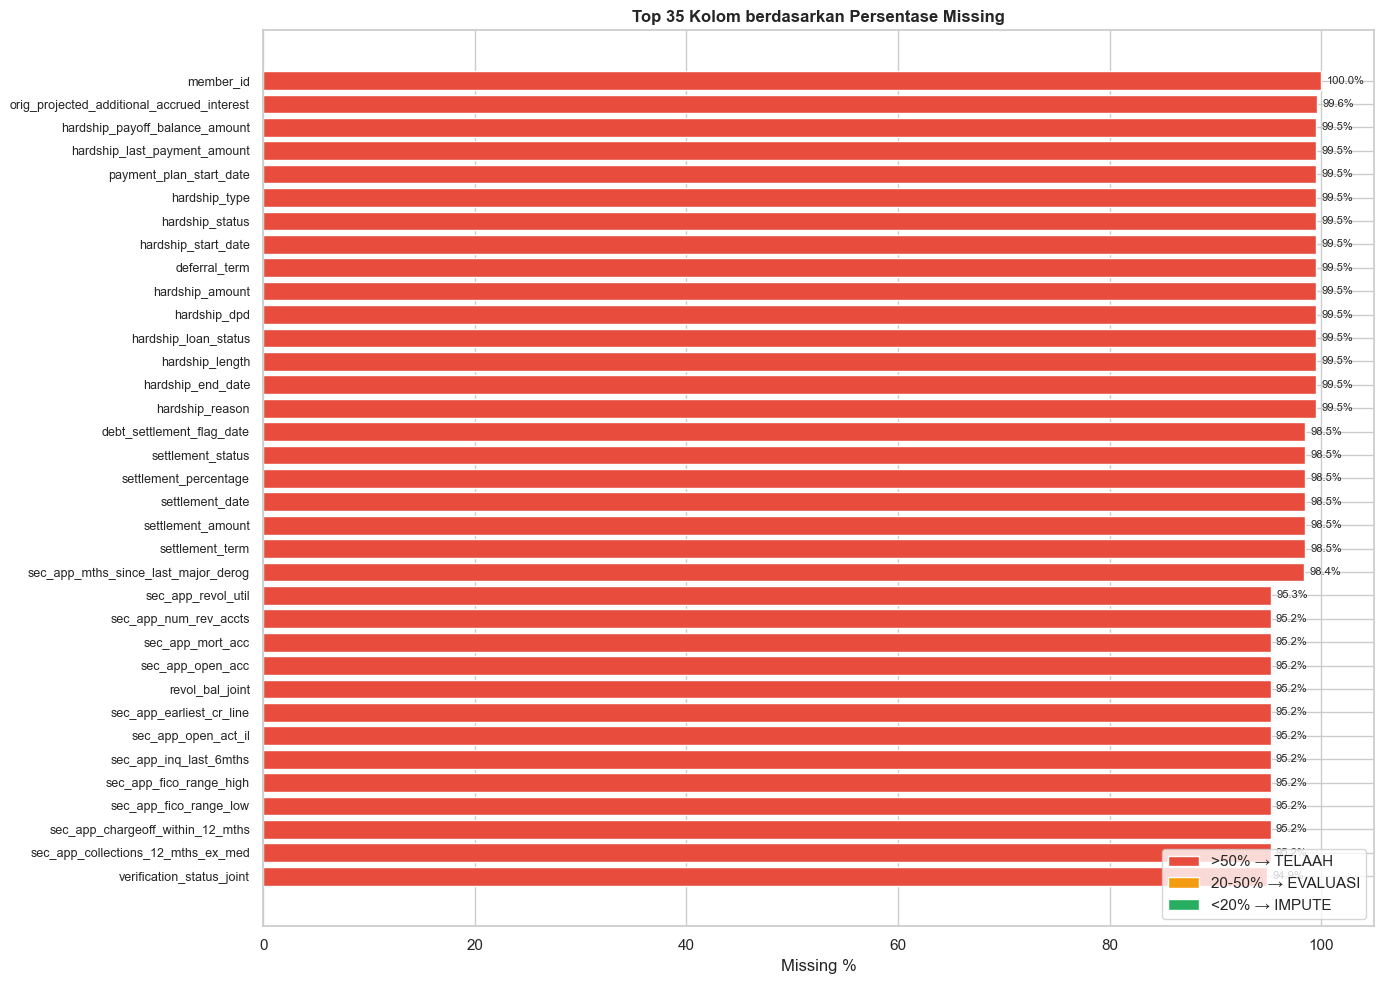

In [151]:
# Visualisasi 35 kolom dengan missing tertinggi
fig, ax = plt.subplots(figsize=(14, 10))
top = missing_df.head(35)
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 20 else '#27ae60' for p in top['Missing %']]
ax.barh(range(len(top)), top['Missing %'].values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel('Missing %'); ax.set_title('Top 35 Kolom berdasarkan Persentase Missing', fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top['Missing %'].values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='>50% → TELAAH'),
                   Patch(facecolor='#f39c12', label='20-50% → EVALUASI'),
                   Patch(facecolor='#27ae60', label='<20% → IMPUTE')], loc='lower right')
plt.tight_layout(); plt.show()

### 1.5: Distribusi Fitur Numerik (Seluruh Fitur)

Deteksi fitur numerik dilakukan otomatis (by dtype), bukan daftar manual. Tabel ringkasan menghitung statistik untuk **semua** fitur numerik: mean/std/min/max, skewness, kurtosis, persentase missing, dan persentase outlier metode IQR. Histogram dibuat untuk seluruh fitur; warna merah menandai |skew| > 1 (kandidat transformasi log di Step 3).

In [152]:
# Deteksi otomatis seluruh fitur numerik (kecuali identifier / kode konstan)
exclude = {'id', 'member_id', 'policy_code'}
numeric_all = [c for c in df_eda.select_dtypes(include=[np.number]).columns if c not in exclude]
print(f'Fitur numerik terdeteksi: {len(numeric_all)} kolom')

def iqr_outlier_pct(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75); iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() * 100

# Tabel ringkasan LENGKAP untuk semua fitur numerik (statistik dari data penuh)
summary = df_eda[numeric_all].describe().T
summary['skew']          = df_eda[numeric_all].skew()
summary['kurtosis']      = df_eda[numeric_all].kurtosis()
summary['missing_%']     = df_eda[numeric_all].isnull().mean() * 100
summary['outlier_iqr_%'] = [iqr_outlier_pct(df_eda[c]) for c in numeric_all]
summary_numeric = summary.sort_values('skew', ascending=False)
print(f'Fitur |skew| > 1: {(summary_numeric["skew"].abs() > 1).sum()}')
summary_numeric.round(2)

Fitur numerik terdeteksi: 111 kolom
Fitur |skew| > 1: 84


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,missing_%,outlier_iqr_%
tot_coll_amt,2190392.0,232.73,8518.46,0.0,0.0,0.0,0.0,9152545.0,852.01,803765.25,3.11,15.26
annual_inc,2260664.0,77992.43,112696.20,0.0,46000.0,65000.0,93000.0,110000000.0,493.89,439001.66,0.00,4.87
delinq_amnt,2260639.0,12.37,726.46,0.0,0.0,0.0,0.0,249925.0,102.65,16006.00,0.00,0.32
num_tl_120dpd_2m,2107011.0,0.00,0.03,0.0,0.0,0.0,0.0,7.0,55.81,5541.59,6.80,0.06
total_rev_hi_lim,2190392.0,34573.95,36728.50,0.0,14700.0,25400.0,43200.0,9999999.0,32.56,7520.93,3.11,5.80
...,...,...,...,...,...,...,...,...,...,...,...,...
bc_util,2184597.0,57.90,28.58,0.0,35.4,60.2,83.1,339.6,-0.27,-1.00,3.37,0.00
mths_since_last_record,359156.0,72.31,26.46,0.0,55.0,74.0,92.0,129.0,-0.37,-0.41,84.11,0.00
last_fico_range_high,2260668.0,687.66,72.97,0.0,654.0,699.0,734.0,850.0,-0.76,0.92,0.00,4.35
pct_tl_nvr_dlq,2190237.0,94.11,9.04,0.0,91.3,100.0,100.0,100.0,-2.28,6.85,3.12,6.80


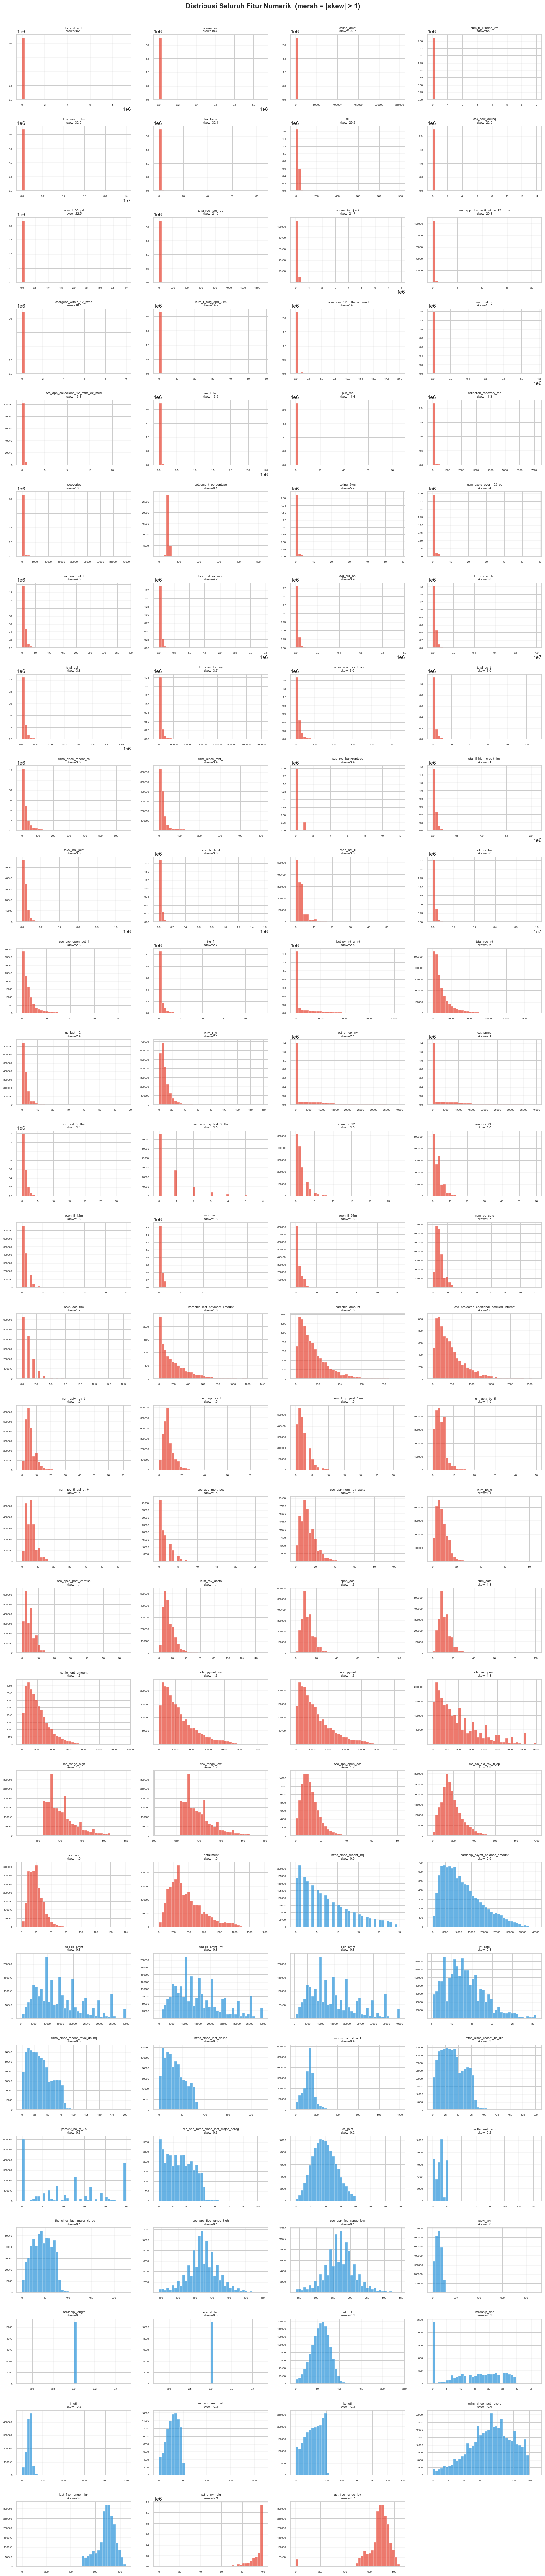

In [153]:
# Histogram seluruh fitur numerik (grid dinamis). KDE dilewati agar cepat pada data penuh.
cols = list(summary_numeric.index)
ncol = 4; nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*4.2, nrow*2.8))
axes = axes.flatten()
for i, col in enumerate(cols):
    ax = axes[i]; d = df_eda[col].dropna(); sk = d.skew()
    ax.hist(d, bins=40, color='#e74c3c' if abs(sk) > 1 else '#3498db', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col}\nskew={sk:.1f}', fontsize=7)
    ax.tick_params(labelsize=6)
for j in range(len(cols), len(axes)):
    axes[j].axis('off')
plt.suptitle('Distribusi Seluruh Fitur Numerik  (merah = |skew| > 1)', fontsize=15, fontweight='bold', y=1.002)
plt.tight_layout(); plt.show()

### 1.6: Deteksi Outlier (Seluruh Fitur Numerik)

Persentase outlier metode IQR (1,5×) sudah dihitung untuk semua fitur pada tabel 1.5. Di bawah, fitur diurutkan berdasarkan proporsi outlier tertinggi, lalu divisualisasikan dengan boxplot. Untuk menjaga kecepatan render pada data penuh, boxplot menggunakan sample acak (statistik ringkasan tetap dari data penuh).

=== FITUR DENGAN OUTLIER IQR TERTINGGI ===
                         outlier_iqr_%    skew
num_accts_ever_120_pd            22.96    5.43
delinq_2yrs                      18.65    5.93
pub_rec                          15.83   11.38
tot_coll_amt                     15.26  852.01
last_pymnt_amnt                  13.86    2.57
inq_fi                           12.35    2.67
pub_rec_bankruptcies             12.04    3.37
settlement_percentage            11.65    9.12
out_prncp_inv                     9.39    2.07
out_prncp                         9.39    2.07
open_acc_6m                       9.20    1.68
mths_since_rcnt_il                8.72    3.43
mths_since_recent_bc              8.51    3.51
open_act_il                       8.32    2.98
bc_open_to_buy                    8.25    3.74
recoveries                        8.20   10.61
collection_recovery_fee           7.83   11.34
mo_sin_rcnt_rev_tl_op             7.81    3.59
total_cu_tl                       7.24    3.58
total_rec_int    

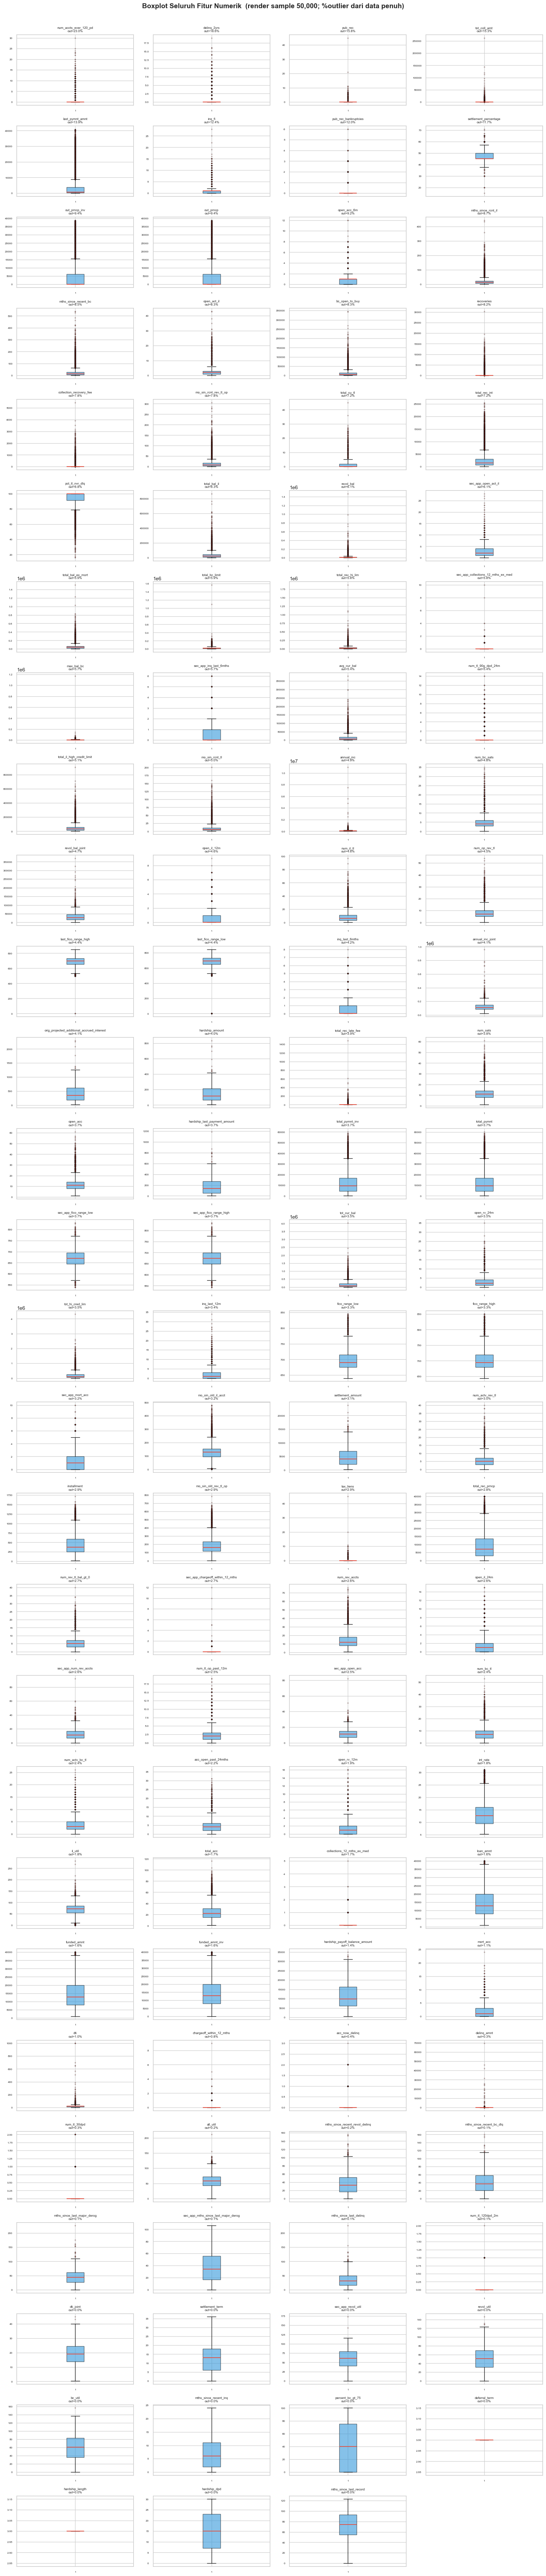

In [154]:
# Ranking fitur berdasarkan proporsi outlier IQR
outlier_rank = summary_numeric[['outlier_iqr_%', 'skew']].sort_values('outlier_iqr_%', ascending=False)
print('=== FITUR DENGAN OUTLIER IQR TERTINGGI ===')
print(outlier_rank.head(20).round(2))

# Boxplot seluruh fitur numerik (render di atas sample agar cepat)
BOX_SAMPLE = 50_000
df_box = df_eda[numeric_all].sample(min(BOX_SAMPLE, len(df_eda)), random_state=RANDOM_SEED)
cols = list(outlier_rank.index)
ncol = 4; nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*4.2, nrow*2.8))
axes = axes.flatten()
for i, col in enumerate(cols):
    ax = axes[i]; d = df_box[col].dropna()
    ax.boxplot(d, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='#e74c3c', linewidth=1.5),
               flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=2, alpha=0.25))
    ax.set_title(f'{col}\nout={summary_numeric.loc[col, "outlier_iqr_%"]:.1f}%', fontsize=7)
    ax.tick_params(labelsize=6)
for j in range(len(cols), len(axes)):
    axes[j].axis('off')
plt.suptitle(f'Boxplot Seluruh Fitur Numerik  (render sample {BOX_SAMPLE:,}; %outlier dari data penuh)',
             fontsize=15, fontweight='bold', y=1.002)
plt.tight_layout(); plt.show()

### 1.7: Distribusi Fitur Kategorik (Seluruh Fitur)

Fitur kategorik dideteksi otomatis (dtype objek). Tabel ringkasan mencatat jumlah kategori unik, kategori dominan beserta proporsinya, dan persentase missing untuk semua kolom kategorik. Bar chart ditampilkan untuk fitur dengan kardinalitas wajar (≤ 25 kategori); kolom berkardinalitas tinggi (mis. teks bebas) cukup diringkas lewat tabel.

In [155]:
# Deteksi otomatis seluruh fitur kategorik (dtype objek)
cat_all = df.select_dtypes(include=['object']).columns.tolist()
print(f'Fitur kategorik (objek) terdeteksi: {len(cat_all)} kolom')

# Tabel ringkasan seluruh fitur kategorik
rows = []
for c in cat_all:
    vc = df[c].value_counts(dropna=True)
    rows.append({
        'feature': c,
        'n_unique': df[c].nunique(dropna=True),
        'top': vc.index[0] if len(vc) else None,
        'top_freq_%': round(vc.iloc[0] / len(df) * 100, 2) if len(vc) else np.nan,
        'missing_%': round(df[c].isnull().mean() * 100, 2),
    })
summary_cat = pd.DataFrame(rows).sort_values('n_unique').reset_index(drop=True)
summary_cat

Fitur kategorik (objek) terdeteksi: 38 kolom


,feature,n_unique,top,top_freq_%,missing_%
0,hardship_type,1,INTEREST ONLY-3 MONTHS DEFERRAL,0.48,99.52
1,term,2,36 months,71.21,0.00
2,initial_list_status,2,w,67.92,0.00
3,pymnt_plan,2,n,99.97,0.00
4,application_type,2,Individual,94.66,0.00
5,hardship_flag,2,N,99.96,0.00
6,debt_settlement_flag,2,N,98.48,0.00
7,disbursement_method,2,Cash,96.54,0.00
8,hardship_status,3,COMPLETED,0.35,99.52
9,settlement_status,3,ACTIVE,0.65,98.49


Divisualisasikan: 19 fitur (n_unique <= 25). Dilewati (kardinalitas tinggi): ['payment_plan_start_date', 'hardship_start_date', 'hardship_end_date', 'sub_grade', 'addr_state', 'debt_settlement_flag_date', 'settlement_date', 'next_pymnt_d', 'last_pymnt_d', 'issue_d', 'last_credit_pull_d', 'sec_app_earliest_cr_line', 'earliest_cr_line', 'zip_code', 'title', 'desc', 'emp_title', 'url', 'id']


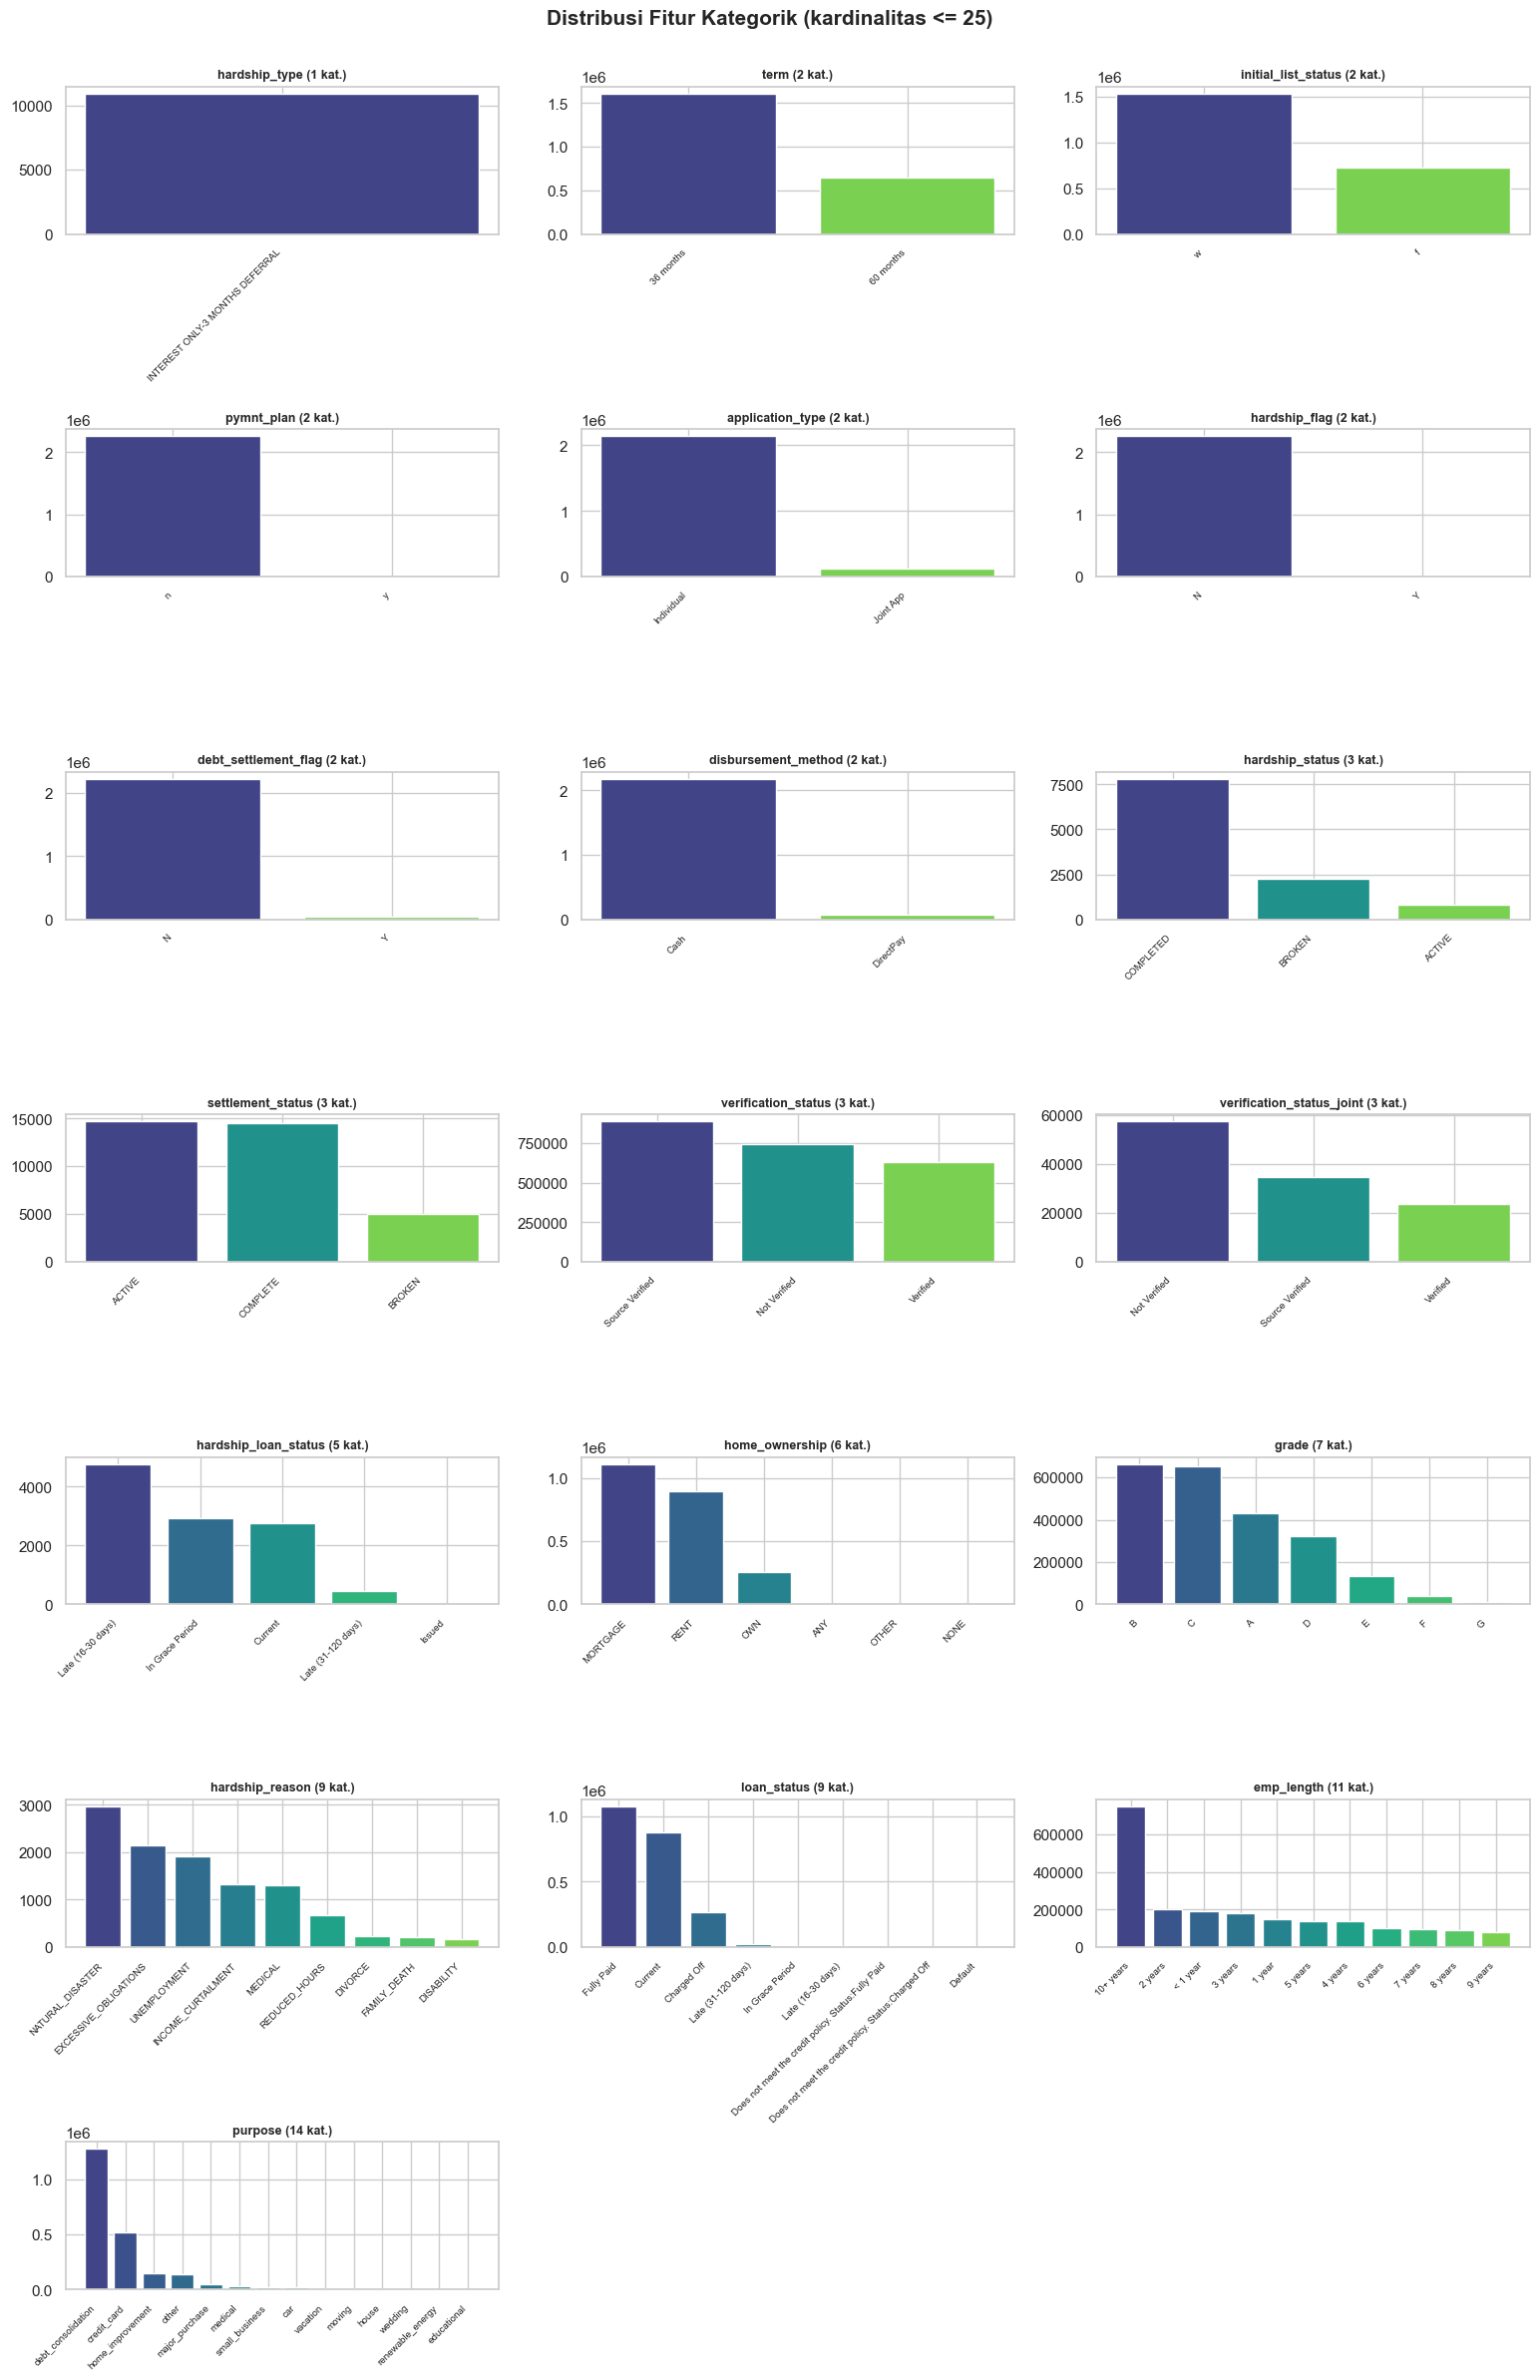

In [156]:
# Bar chart untuk fitur kategorik berkardinalitas wajar (<= 25 kategori)
CARD_MAX = 25
plot_cats = summary_cat.query('n_unique <= @CARD_MAX')['feature'].tolist()
print(f'Divisualisasikan: {len(plot_cats)} fitur (n_unique <= {CARD_MAX}). '
      f'Dilewati (kardinalitas tinggi): {summary_cat.query("n_unique > @CARD_MAX")["feature"].tolist()}')

if plot_cats:
    ncol = 3; nrow = int(np.ceil(len(plot_cats) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*5.2, nrow*3.4))
    axes = np.atleast_1d(axes).flatten()
    for i, col in enumerate(plot_cats):
        ax = axes[i]; counts = df[col].value_counts().head(CARD_MAX)
        palette = plt.cm.viridis(np.linspace(0.2, 0.8, len(counts)))
        ax.bar(range(len(counts)), counts.values, color=palette, edgecolor='white')
        ax.set_xticks(range(len(counts))); ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=7)
        ax.set_title(f'{col} ({df[col].nunique()} kat.)', fontsize=9, fontweight='bold')
    for j in range(len(plot_cats), len(axes)):
        axes[j].axis('off')
    plt.suptitle('Distribusi Fitur Kategorik (kardinalitas <= 25)', fontsize=15, fontweight='bold', y=1.002)
    plt.tight_layout(); plt.show()

### 1.8: Korelasi Antar Fitur Numerik (Seluruh Fitur)

Matriks korelasi Pearson dihitung untuk semua fitur numerik. Heatmap penuh ditampilkan tanpa anotasi angka (terlalu banyak sel untuk dibaca satu per satu); yang lebih berguna adalah daftar lengkap pasangan berkorelasi tinggi (|r| > 0,80) di bawahnya, karena pasangan inilah yang menandai redundansi/multikolinearitas dan menjadi dasar penghapusan fitur di Step 4.

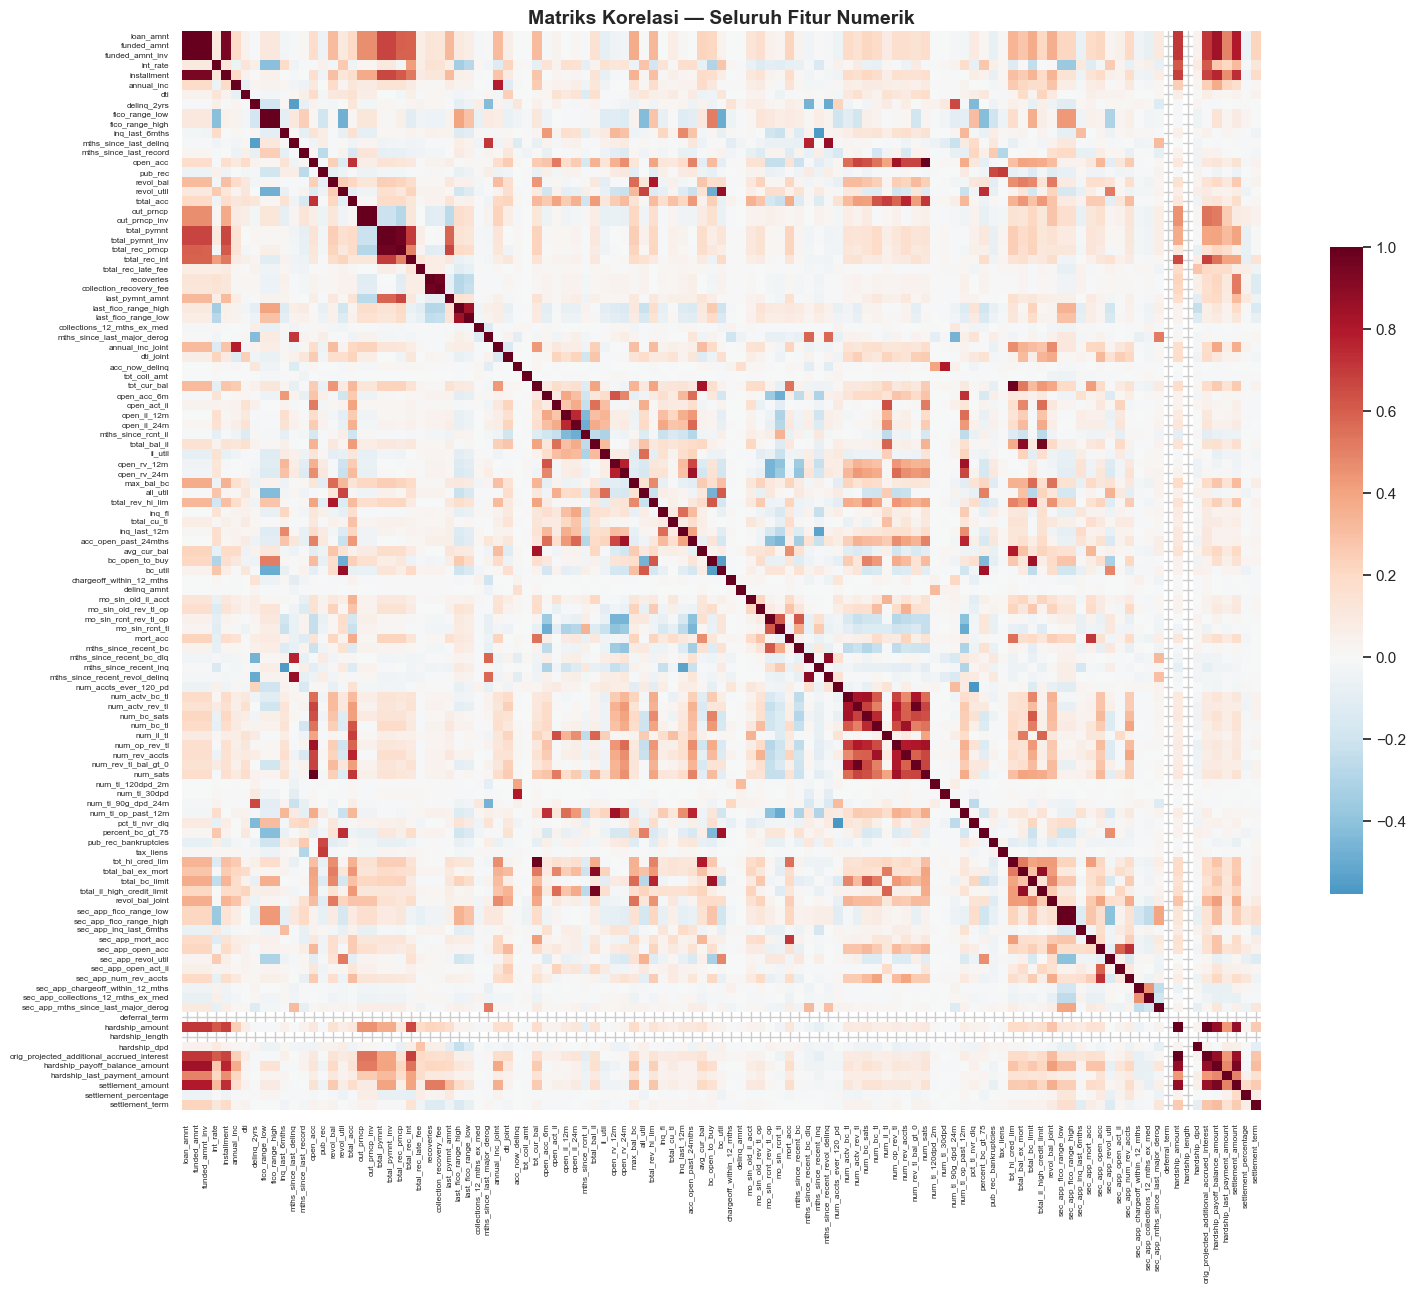

Pasangan dengan |r| > 0.8: 49


,feature_1,feature_2,r
0,hardship_amount,orig_projected_additional_accrued_interest,1.000
1,sec_app_fico_range_low,sec_app_fico_range_high,1.000
2,fico_range_low,fico_range_high,1.000
3,out_prncp,out_prncp_inv,1.000
4,loan_amnt,funded_amnt,1.000
5,total_pymnt,total_pymnt_inv,0.999
6,funded_amnt,funded_amnt_inv,0.999
7,loan_amnt,funded_amnt_inv,0.999
8,open_acc,num_sats,0.999
9,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.984


In [157]:
# Korelasi seluruh fitur numerik (pakai df_eda agar int_rate/revol_util terbaca numerik)
corr_full = df_eda[numeric_all].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_full, cmap='RdBu_r', center=0, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.6}, ax=ax)
ax.tick_params(labelsize=6)
ax.set_title('Matriks Korelasi — Seluruh Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Daftar LENGKAP pasangan berkorelasi tinggi (|r| > 0.80)
THR = 0.80
upper = corr_full.where(np.triu(np.ones(corr_full.shape, dtype=bool), k=1))
pairs = (upper.stack()
              .rename('r').reset_index()
              .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'}))
high_corr = (pairs[pairs['r'].abs() > THR]
             .assign(abs_r=lambda d: d['r'].abs())
             .sort_values('abs_r', ascending=False)
             .drop(columns='abs_r').reset_index(drop=True))
print(f'Pasangan dengan |r| > {THR}: {len(high_corr)}')
high_corr.round(3)

### 1.9: Ringkasan Temuan EDA

Temuan berikut berasal langsung dari output sel 1.3–1.8 pada data penuh (2.260.701 baris).

- **Struktur & tipe.** 151 kolom mentah: 100 `float32`, 13 `float64`, dan 38 `object` (setelah `int_rate` & `revol_util` dikonversi dari string-persen ke numerik). Terdeteksi **111 fitur numerik** dan 38 kolom kategorik.
- **Missing values.** 150 dari 151 kolom memiliki missing; **44 kolom >50%**, 14 kolom 20–50%, 92 kolom <20%. Verifikasi 1.4b **membuktikan** banyak missing bersifat *structural*, bukan acak: kolom `*_joint` 100% kosong saat aplikasi Individual, dan `mths_since_last_delinq` 62,7% kosong pada peminjam tanpa riwayat delinquency. → dasar keputusan: structural ditangani flag+sentinel (bukan drop buta), leakage di-drop, MAR-temporal berambang.
- **Skewness.** **84 dari 111 fitur numerik** ber-|skew|>1; ekstrem pada fitur finansial: `annual_inc` (maks 110 juta, skew ≈494), `tot_coll_amt` (skew 852). → menuntut winsorization + log transform.
- **Outlier.** Proporsi outlier IQR tertinggi pada `num_accts_ever_120_pd` (23%), `delinq_2yrs` (19%), `pub_rec` (16%), banyak fitur *count zero-inflated* dan post-loan yang akan disaring di cleaning/feature-selection.
- **Kategorik.** Ordinal (`grade` 7, `sub_grade` 35, `emp_length` 11); nominal (`purpose` 14, `home_ownership` 6, `addr_state` 51); kardinalitas tinggi non-analitis (`emp_title` 512k, `url` unik/baris, `zip_code` 956).
- **Korelasi.** **49 pasang** |r|>0,80, redundansi kuat (`loan_amnt`–`funded_amnt`–`installment`; `fico_range_low`–`fico_range_high`). → menuntun penghapusan multikolinearitas di Step 4.

**Implikasi → Step 2 (Cleaning):** drop identifier/teks/leakage, tangani structural vs MAR vs MCAR sesuai mekanisme yang telah diverifikasi, hapus duplikat.

---
## Step 2: Data Cleaning

Tujuan: memperbaiki inkonsistensi tipe/format, menghapus kolom yang tidak relevan (identifier, teks bebas, konstan) dan kolom *post-loan* (data leakage), menangani missing values sesuai mekanismenya (dari telaah Step 1), lalu menghapus duplikat. Encoding kategorik, transformasi (log), scaling, dan penanganan outlier **dilakukan di Step 3**, bukan di sini.

Keputusan penanganan missing (best practice):
- `mths_since_*` (structural) → flag biner `*_present` + isi NaN dengan sentinel 999.
- joint/sec_app (sparse) → drop kolomnya, simpan flag `is_joint`.
- Sisa missing rendah → impute median (numerik) / modus (kategorik).

### 2.1: Perbaiki Inkonsistensi Tipe & Format

In [158]:
print('Shape awal Step 2:', df.shape)

# term: ' 36 months' -> 36 (numerik)
if 'term' in df.columns and df['term'].dtype == 'object':
    df['term'] = pd.to_numeric(df['term'].astype(str).str.replace('months', '', regex=False).str.strip(),
                               errors='coerce').astype('Int64')
    print('  term  ->', sorted(df['term'].dropna().unique().tolist()))

# emp_length: '< 1 year'..'10+ years' -> 0..10 (nilai numerik ordinal alami)
emp_map = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,'5 years':5,
           '6 years':6,'7 years':7,'8 years':8,'9 years':9,'10+ years':10}
if 'emp_length' in df.columns and df['emp_length'].dtype == 'object':
    df['emp_length'] = df['emp_length'].map(emp_map)
    print('  emp_length rentang:', df['emp_length'].min(), '-', df['emp_length'].max())

# int_rate & revol_util: sudah dikonversi di Step 1.3 (guard bila notebook dijalankan sebagian)
for c in ['int_rate', 'revol_util']:
    if c in df.columns and df[c].dtype == 'object':
        df[c] = pd.to_numeric(df[c].astype(str).str.replace('%', '', regex=False), errors='coerce')
print('Inkonsistensi tipe diperbaiki.')

Shape awal Step 2: (2260701, 151)
  term  -> [36, 60]
  emp_length rentang: 0.0 - 10.0
Inkonsistensi tipe diperbaiki.


### 2.2: Drop Identifier, Teks Bebas, & Kolom Konstan

Kolom identifier dan teks bebas berkardinalitas sangat tinggi (Step 1.7) tidak dapat dipakai untuk clustering. Kolom konstan (satu nilai unik) tidak membawa informasi.

In [159]:
id_text = ['id', 'member_id', 'url', 'emp_title', 'title', 'desc', 'zip_code']
const_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
drop_now = [c for c in set(id_text + const_cols) if c in df.columns]

print('Drop identifier/teks bebas :', [c for c in id_text if c in df.columns])
print('Drop kolom konstan         :', const_cols)
df.drop(columns=drop_now, inplace=True, errors='ignore')
print('Shape:', df.shape)

Drop identifier/teks bebas : ['id', 'member_id', 'url', 'emp_title', 'title', 'desc', 'zip_code']
Drop kolom konstan         : ['member_id', 'policy_code', 'hardship_type', 'deferral_term', 'hardship_length']
Shape: (2260701, 140)


### 2.3: Drop Kolom Post-Loan (Data Leakage) & Tanggal Tak Terpakai

Kolom yang nilainya baru terbentuk **setelah** pinjaman berjalan (pembayaran, recovery, hardship, settlement, FICO terkini) bukan karakteristik peminjam saat pengajuan, sehingga tidak boleh menjadi fitur clustering. `loan_status` dipertahankan **terpisah** sebagai label referensi (bukan fitur).

In [160]:
post_loan = ['funded_amnt','funded_amnt_inv','out_prncp','out_prncp_inv',
             'total_pymnt','total_pymnt_inv','total_rec_prncp','total_rec_int','total_rec_late_fee',
             'recoveries','collection_recovery_fee','last_pymnt_amnt',
             'last_fico_range_high','last_fico_range_low','collections_12_mths_ex_med']
# hardship_* & settlement_* & debt_settlement* (semua post-loan) via prefix
post_loan += [c for c in df.columns if c.startswith('hardship_') or c.startswith('settlement_')
              or c.startswith('debt_settlement')]
# Kolom tanggal (string) yang tak dipakai langsung untuk clustering
date_cols = ['issue_d','last_pymnt_d','next_pymnt_d','last_credit_pull_d','earliest_cr_line']

drop_leak = [c for c in set(post_loan + date_cols) if c in df.columns and c != 'loan_status']
print(f'Drop {len(drop_leak)} kolom post-loan/leakage + tanggal.')
df.drop(columns=drop_leak, inplace=True, errors='ignore')

# loan_status dipertahankan sbg kolom sampai akhir Step 2 (dipisah setelah dedup agar baris selaras)
print('loan_status dipertahankan sementara sbg label referensi.')
print('Shape:', df.shape)

Drop 37 kolom post-loan/leakage + tanggal.
loan_status dipertahankan sementara sbg label referensi.
Shape: (2260701, 103)


### 2.4: Structural Missing `mths_since_*` → Flag + Sentinel

NaN pada `mths_since_*` berarti event (delinquency, catatan publik, dsb.) **tidak pernah terjadi**, informasi bermakna, bukan data hilang acak. Ditangani dengan flag biner `*_present` (1 = pernah terjadi) dan pengisian sentinel 999 (bulan) yang menjaga urutan 'semakin lama semakin besar'.

In [161]:
mths_cols = [c for c in df.columns if c.startswith('mths_since')]
SENTINEL = 999
print(f'{len(mths_cols)} kolom mths_since_* -> flag + sentinel {SENTINEL}')
for c in mths_cols:
    df[c + '_present'] = df[c].notna().astype('int8')   # 1 = event pernah terjadi
    df[c] = df[c].fillna(SENTINEL)
print('Contoh flag:', [c + '_present' for c in mths_cols][:4])
print('Shape:', df.shape)

8 kolom mths_since_* -> flag + sentinel 999
Contoh flag: ['mths_since_last_delinq_present', 'mths_since_last_record_present', 'mths_since_last_major_derog_present', 'mths_since_rcnt_il_present']
Shape: (2260701, 111)


### 2.5: Joint/Sec-App → Drop Sparse + Flag `is_joint`

Mayoritas pinjaman bersifat individual, sehingga kolom joint/sec-app hampir seluruhnya kosong (Step 1.4b). Kolomnya di-drop; keberadaan aplikasi bersama diringkas menjadi satu flag `is_joint`.

In [162]:
is_joint = None
if 'application_type' in df.columns:
    is_joint = df['application_type'].astype(str).str.contains('Joint').astype('int8')

joint_cols = [c for c in df.columns if 'joint' in c.lower() or c.lower().startswith('sec_app_')]
print(f'Drop {len(joint_cols)} kolom joint/sec_app (sparse).')
df.drop(columns=joint_cols, inplace=True, errors='ignore')

if is_joint is not None:
    df['is_joint'] = is_joint
    df.drop(columns=['application_type'], inplace=True, errors='ignore')  # redundan dgn is_joint
    print('is_joint dibuat. Distribusi:', dict(df['is_joint'].value_counts()))
print('Shape:', df.shape)

Drop 16 kolom joint/sec_app (sparse).
is_joint dibuat. Distribusi: {0: np.int64(2139991), 1: np.int64(120710)}
Shape: (2260701, 95)


### 2.6: Drop Kolom High-Missing (Ambang 40%)

Kolom yang masih memiliki missing tinggi setelah penanganan structural umumnya berasal dari perluasan skema kredit yang hanya terisi pada periode/aplikasi tertentu (MAR temporal, mis. gugus `il_`/`util`). Karena clustering berbasis jarak Euclidean, mengimputasi 30–40% nilai dengan satu angka median akan menciptakan tumpukan artifisial yang mendistorsi jarak, dan juga mengontaminasi feature selection di Step 4. Karena itu diterapkan ambang **>40% missing → drop** (praktik umum; naikkan ke 35% bila ingin lebih ketat). Fitur dengan missing lebih rendah dipertahankan dan diimputasi di Step 2.7.

In [163]:
MISS_THRESHOLD = 40   # ambang drop (%). 40 = praktik umum; set 35 untuk lebih ketat.
miss_now = df.isnull().mean() * 100
high_missing = miss_now[miss_now > MISS_THRESHOLD].index.tolist()
high_missing = [c for c in high_missing if c != 'loan_status']
print(f'Drop {len(high_missing)} kolom dengan missing > {MISS_THRESHOLD}%:')
for c in high_missing:
    print(f'  x {c} ({miss_now[c]:.1f}%)')
df.drop(columns=high_missing, inplace=True, errors='ignore')
print('Shape:', df.shape)

Drop 3 kolom dengan missing > 40%:
  x il_util (47.3%)
  x payment_plan_start_date (99.5%)
  x orig_projected_additional_accrued_interest (99.6%)
Shape: (2260701, 92)


### 2.7: Impute Sisa Missing Rendah (Median / Modus)

Sisa missing (proporsi rendah, mendekati MCAR) diimputasi: numerik dengan median (robust terhadap skew), kategorik dengan modus. **Pengecualian `mort_acc`**: diimputasi berbasis grup, rata-rata `mort_acc` per nilai `total_acc`, karena keduanya berkorelasi (praktik umum pada dataset ini), sehingga lebih akurat daripada median global. Fallback median dipakai untuk nilai `total_acc` yang langka. Seluruh baris dipertahankan.

In [164]:
# Imputasi khusus mort_acc berbasis grup total_acc (lebih akurat dari median global)
if {'mort_acc', 'total_acc'}.issubset(df.columns) and df['mort_acc'].isnull().any():
    grp_mean = df.groupby('total_acc')['mort_acc'].transform('mean')   # vektorisasi, cepat
    df['mort_acc'] = df['mort_acc'].fillna(grp_mean)
    df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].median())     # fallback total_acc langka
    print('mort_acc: imputasi berbasis grup total_acc (fallback median global).')

rem = df.isnull().sum(); rem = rem[rem > 0]
num_na = [c for c in rem.index if pd.api.types.is_numeric_dtype(df[c]) and c != 'loan_status']
cat_na = [c for c in rem.index if c not in num_na and c != 'loan_status']

for c in num_na:
    df[c] = df[c].fillna(df[c].median())
for c in cat_na:
    df[c] = df[c].fillna(df[c].mode().iloc[0])

print(f'Imputasi -> median: {len(num_na)} numerik | modus: {len(cat_na)} kategorik')
# loan_status: baris tanpa label referensi dibuang (label tidak diimputasi)
if 'loan_status' in df.columns and df['loan_status'].isnull().any():
    df = df[df['loan_status'].notna()].reset_index(drop=True)
print('Sisa missing (fitur):', int(df.drop(columns=['loan_status'], errors='ignore').isnull().sum().sum()))

mort_acc: imputasi berbasis grup total_acc (fallback median global).
Imputasi -> median: 64 numerik | modus: 9 kategorik
Sisa missing (fitur): 0


### 2.8: Hapus Duplikat & Pisahkan Label Referensi

Duplikat baris penuh dihapus. Setelah itu `loan_status` dipisahkan menjadi label referensi (`loan_status_ref`) yang selaras baris dengan dataset fitur.

In [165]:
dup = df.duplicated().sum()
print('Baris duplikat penuh:', f'{dup:,}')
if dup > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

# Pisahkan label referensi setelah dedup (baris selaras)
if 'loan_status' in df.columns:
    loan_status_ref = df['loan_status'].copy()
    df.drop(columns=['loan_status'], inplace=True)
    print('loan_status_ref dipisah. Distribusi:', dict(loan_status_ref.value_counts()))
print('Shape fitur setelah dedup:', df.shape)

Baris duplikat penuh: 0
loan_status_ref dipisah. Distribusi: {'Fully Paid': np.int64(1076751), 'Current': np.int64(878317), 'Charged Off': np.int64(268559), 'Late (31-120 days)': np.int64(21467), 'In Grace Period': np.int64(8436), 'Late (16-30 days)': np.int64(4349), 'Does not meet the credit policy. Status:Fully Paid': np.int64(1988), 'Does not meet the credit policy. Status:Charged Off': np.int64(761), 'Default': np.int64(40)}
Shape fitur setelah dedup: (2260668, 91)


### 2.9: Ringkasan Hasil Cleaning

In [166]:
print('=== DATA CLEANING SELESAI ===')
print(f'  Baris          : {df.shape[0]:,}')
print(f'  Kolom (fitur)  : {df.shape[1]}')
print(f'  Missing total  : {int(df.isnull().sum().sum())}')
print(f'  Label referensi: loan_status_ref ({len(loan_status_ref):,} baris)')

num_c = df.select_dtypes(include=[np.number]).shape[1]
obj_c = df.select_dtypes(include=["object"]).shape[1]
print(f'\n  Tipe: {num_c} numerik, {obj_c} kategorik (objek) -> encoding di Step 3')
print('\nDaftar kolom akhir:')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c} ({df[c].dtype})')

=== DATA CLEANING SELESAI ===
  Baris          : 2,260,668
  Kolom (fitur)  : 91
  Missing total  : 0
  Label referensi: loan_status_ref (2,260,668 baris)

  Tipe: 82 numerik, 9 kategorik (objek) -> encoding di Step 3

Daftar kolom akhir:
   1. loan_amnt (float32)
   2. term (Int64)
   3. int_rate (float32)
   4. installment (float32)
   5. grade (object)
   6. sub_grade (object)
   7. emp_length (float64)
   8. home_ownership (object)
   9. annual_inc (float64)
  10. verification_status (object)
  11. pymnt_plan (object)
  12. purpose (object)
  13. addr_state (object)
  14. dti (float32)
  15. delinq_2yrs (float32)
  16. fico_range_low (float32)
  17. fico_range_high (float32)
  18. inq_last_6mths (float32)
  19. mths_since_last_delinq (float32)
  20. mths_since_last_record (float32)
  21. open_acc (float32)
  22. pub_rec (float32)
  23. revol_bal (float32)
  24. revol_util (float32)
  25. total_acc (float32)
  26. initial_list_status (object)
  27. mths_since_last_major_derog (float

---
## Step 3: Data Transformation

Tujuan: menyiapkan fitur agar siap untuk clustering. Urutan mengikuti ketentuan: **encoding → binning (untuk reporting/Phase 3) → winsorization → log transform → scaling**.

Keputusan desain transformasi:
- Fitur **nominal** (home_ownership, purpose, addr_state, verification_status) **tidak** di-one-hot, pada clustering berbasis jarak Euclidean, one-hot mendistorsi jarak dan menciptakan sparsity semu. Nominal murni **di-drop** dari matriks clustering (disalin dulu untuk Phase 3 ARM).
- Fitur **ordinal** (`grade`, `sub_grade`) dipertahankan via ordinal encoding yang merefleksikan urutan aslinya.
- `emp_length`, `term` sudah numerik sejak Step 2.
- Kolom MAR-temporal (`il_`/`util`) sementara dipertahankan; evaluasi/pruning dilakukan di **Step 4 (feature selection)**.

### 3.1: Encoding Kategorik (Ordinal & Biner) + Drop Nominal

In [167]:
print('Shape awal Step 3:', df.shape)

# Salin kolom nominal untuk Phase 3 (Association Rule Mining) sebelum di-drop dari clustering
nominal_for_arm = [c for c in ['purpose','home_ownership','verification_status','addr_state'] if c in df.columns]
df_nominal = df[nominal_for_arm].copy()
print('Kolom nominal disalin utk Phase 3 ARM:', nominal_for_arm)

# term: Int64 -> float (agar kompatibel dengan scaler)
if 'term' in df.columns:
    df['term'] = df['term'].astype('float32')

# Ordinal encoding grade (A=1..G=7) & sub_grade (A1=1..G5=35)
if 'grade' in df.columns and df['grade'].dtype == 'object':
    df['grade'] = df['grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}).astype('float32')
    print('  grade -> ordinal (A=1..G=7)')
if 'sub_grade' in df.columns and df['sub_grade'].dtype == 'object':
    sg = sorted(df['sub_grade'].dropna().unique())
    df['sub_grade'] = df['sub_grade'].map({s:i+1 for i,s in enumerate(sg)}).astype('float32')
    print(f'  sub_grade -> ordinal (A1=1..{sg[-1]}={len(sg)})')

# Biner
if 'initial_list_status' in df.columns and df['initial_list_status'].dtype == 'object':
    df['initial_list_status'] = (df['initial_list_status'] == 'w').astype('int8')
    print('  initial_list_status -> biner (f=0, w=1)')

# Drop nominal murni dari matriks clustering (bukan one-hot; alasan di markdown atas)
drop_nominal = [c for c in ['home_ownership','purpose','addr_state','verification_status',
                            'pymnt_plan','disbursement_method'] if c in df.columns]
df.drop(columns=drop_nominal, inplace=True, errors='ignore')
print('Drop nominal (clustering):', drop_nominal)

# Catch-all: buang SISA kolom object apa pun (nominal) agar tidak lolos ke scaling (3.6).
# Aman terhadap perbedaan sample vs data penuh (mis. kolom yang di sample konstan tapi tidak di data penuh).
leftover_obj = df.select_dtypes(include='object').columns.tolist()
if leftover_obj:
    df.drop(columns=leftover_obj, inplace=True)
    print('Drop sisa kolom nominal (catch-all):', leftover_obj)
print('Sisa kolom object:', df.select_dtypes(include='object').columns.tolist(), '| Shape:', df.shape)

Shape awal Step 3: (2260668, 91)
Kolom nominal disalin utk Phase 3 ARM: ['purpose', 'home_ownership', 'verification_status', 'addr_state']
  grade -> ordinal (A=1..G=7)
  sub_grade -> ordinal (A1=1..G5=35)
  initial_list_status -> biner (f=0, w=1)
Drop nominal (clustering): ['home_ownership', 'purpose', 'addr_state', 'verification_status', 'pymnt_plan', 'disbursement_method']
Sisa kolom object: [] | Shape: (2260668, 85)


### 3.2: Binning Variabel Kontinu (untuk Reporting & Phase 3 ARM)

Binning dilakukan pada nilai **asli** (sebelum transformasi) agar batas bin bermakna secara domain. Hasilnya dipakai untuk analisis deskriptif dan sebagai input diskretisasi Phase 3. Nilai kontinu asli **tetap** dipertahankan untuk clustering.

In [168]:
bin_specs = {
    'annual_inc':    (4, ['Low','Medium','High','Very High']),
    'dti':           (4, ['Low','Medium','High','Very High']),
    'int_rate':      (4, ['Low','Medium','High','Very High']),
    'loan_amnt':     (4, ['Small','Medium','Large','Very Large']),
    'fico_range_low':(5, ['Very Low','Low','Medium','High','Very High']),
}
df_binned = pd.DataFrame(index=df.index)
for col, (q, labels) in bin_specs.items():
    if col in df.columns:
        df_binned[col + '_bin'] = pd.qcut(df[col], q=q, labels=labels, duplicates='drop')

# Dataset untuk Phase 3 ARM: binned kontinu + nominal + grade (ordinal dikembalikan ke label kategori)
arm_df = pd.concat([df_binned, df_nominal.reset_index(drop=True)], axis=1)
print('Binning selesai. Kolom bin:', list(df_binned.columns))
print('arm_df (Phase 3) shape:', arm_df.shape)
df_binned.head(3)

Binning selesai. Kolom bin: ['annual_inc_bin', 'dti_bin', 'int_rate_bin', 'loan_amnt_bin', 'fico_range_low_bin']
arm_df (Phase 3) shape: (2260668, 9)


,annual_inc_bin,dti_bin,int_rate_bin,loan_amnt_bin,fico_range_low_bin
0,Medium,Low,High,Small,Low
1,Medium,Medium,Medium,Very Large,High
2,Medium,Low,Medium,Large,Medium


### 3.3: Winsorization Outlier (Data-Driven)

Setiap fitur **kontinu** ber-|skew| > 1 di-cap pada persentil 1/99, dengan **guard q99>median** agar fitur zero-inflated tidak kolaps menjadi konstan. Pendekatan **data-driven** ini (bukan daftar kolom hardcode) menangani heavy-tail secara sistematis, termasuk fitur yang baru muncul relevan. Diterapkan **sebelum** log transform.

> **Untuk Phase 4:** sebelum winsorization, snapshot nilai asli disimpan (`df_prewinsor`). Anomaly detection **tidak boleh** memakai data ter-winsorize karena justru akan menghapus anomali yang dicari.

In [169]:
# Snapshot nilai ASLI (pre-winsor, pre-log) untuk Phase 4 (Anomaly Detection).
df_prewinsor = df.copy()

WINSORIZE = True
WINSOR_SKEW_THRESHOLD = 1.0
# Fitur kontinu = numerik minus ordinal/biner/flag
_excl = set(['grade','sub_grade','term','emp_length','is_joint','initial_list_status']
            + [c for c in df.columns if c.endswith('_present')])
_cont = [c for c in df.select_dtypes(include=[np.number]).columns if c not in _excl]

if WINSORIZE:
    _sk = df[_cont].skew().abs()
    targets = [c for c in _cont if _sk[c] > WINSOR_SKEW_THRESHOLD]
    winsorized, skipped = [], []
    for c in targets:
        q50, q99 = df[c].quantile(0.50), df[c].quantile(0.99)
        if q99 > q50:                      # guard: hindari kolaps zero-inflated
            df[c] = df[c].clip(df[c].quantile(0.01), q99)
            winsorized.append(c)
        else:
            skipped.append(c)
    print(f'Winsorization 1/99 data-driven (|skew|>{WINSOR_SKEW_THRESHOLD}): {len(winsorized)} fitur.')
    if skipped:
        print(f'Dilewati (zero-inflated, q99<=median): {len(skipped)} fitur.')
else:
    print('Winsorization dilewati (WINSORIZE=False).')

Winsorization 1/99 data-driven (|skew|>1.0): 52 fitur.
Dilewati (zero-inflated, q99<=median): 9 fitur.


### 3.4: Log Transform Fitur Skewed

`np.log1p` diterapkan pada fitur kontinu non-negatif dengan |skew| > 1, mengecilkan ekor distribusi sebelum scaling. Ordinal (`grade`, `sub_grade`, `emp_length`, `term`), biner, dan flag `*_present` dikecualikan.

In [170]:
exclude_log = set(['grade','sub_grade','term','emp_length','is_joint','initial_list_status']
                  + [c for c in df.columns if c.endswith('_present')])
cont_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_log]
skew = df[cont_cols].skew()
log_cand = [c for c in cont_cols if abs(skew[c]) > 1 and (df[c] >= 0).all()]

# Terapkan log1p HANYA bila benar-benar mengurangi |skew| (hindari over-correction).
log_applied, reverted = [], []
for c in log_cand:
    before = abs(df[c].skew())
    trans = np.log1p(df[c])
    if abs(trans.skew()) < before:
        df[c] = trans
        log_applied.append(c)
    else:
        reverted.append(c)

print(f'Kandidat log (|skew|>1, non-negatif): {len(log_cand)}')
print(f'Log1p diterapkan: {len(log_applied)} | dibatalkan krn tak memperbaiki: {len(reverted)}')
if reverted:
    print('  dibatalkan:', reverted[:12])
if log_applied:
    print(f'Rata-rata |skew| fitur ter-log: '
          f'{df[log_applied].skew().abs().mean():.2f}')

Kandidat log (|skew|>1, non-negatif): 56
Log1p diterapkan: 46 | dibatalkan krn tak memperbaiki: 10
  dibatalkan: ['mths_since_last_record', 'mths_since_last_major_derog', 'total_bal_il', 'max_bal_bc', 'mths_since_recent_bc_dlq', 'pct_tl_nvr_dlq', 'pub_rec_bankruptcies', 'tax_liens', 'total_bc_limit', 'total_il_high_credit_limit']
Rata-rata |skew| fitur ter-log: 3.16


### 3.5: Buang Fitur Quasi-Constant

Fitur yang nilai dominannya menutupi hampir seluruh baris (di sini ≥99%) nyaris tidak membawa informasi pembeda untuk clustering. Ini menangani secara sistematis fitur **count zero-inflated** (mis. `acc_now_delinq`, `chargeoff_within_12_mths`, `num_tl_120dpd_2m`) yang tetap sangat skewed meski sudah di-log, karena >99% nilainya sama (0). Fitur inti mining angle diproteksi agar tidak ikut terbuang.

In [171]:
QUASI_CONST = 0.99   # buang fitur yang satu nilai menutupi >= 99% baris
protect = {'grade','sub_grade','annual_inc','dti','int_rate','fico_range_low',
           'fico_range_high','emp_length','loan_amnt','revol_util','term'}
dom_ratio = df.apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
quasi = [c for c in dom_ratio[dom_ratio >= QUASI_CONST].index if c not in protect]

if quasi:
    df.drop(columns=quasi, inplace=True)
    print(f'Drop {len(quasi)} fitur quasi-constant (nilai dominan >= {QUASI_CONST:.0%}):')
    for c in quasi:
        print(f'  x {c} ({dom_ratio[c]*100:.1f}% satu nilai)')
else:
    print('Tidak ada fitur quasi-constant.')
print('Shape sebelum scaling:', df.shape)

Drop 5 fitur quasi-constant (nilai dominan >= 99%):
  x acc_now_delinq (99.6% satu nilai)
  x chargeoff_within_12_mths (99.2% satu nilai)
  x delinq_amnt (99.7% satu nilai)
  x num_tl_120dpd_2m (99.9% satu nilai)
  x num_tl_30dpd (99.7% satu nilai)
Shape sebelum scaling: (2260668, 80)


### 3.6: Standard Scaling

StandardScaler menstandardkan seluruh fitur ke mean 0 dan standar deviasi 1, syarat agar clustering berbasis jarak tidak didominasi fitur berskala besar. Urutan: **log transform (3.4) → scaling (di sini)**.

In [172]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index).astype('float32')

print('StandardScaler diterapkan.')
print(f'  Shape        : {df_scaled.shape}')
print(f'  Mean rata2   : {df_scaled.mean().mean():.6f}  (≈0)')
print(f'  Std  rata2   : {df_scaled.std().mean():.4f}  (≈1)')
df_scaled.head(3)

StandardScaler diterapkan.
  Shape        : (2260668, 80)
  Mean rata2   : -0.000000  (≈0)
  Std  rata2   : 1.0000  (≈1)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,dti,delinq_2yrs,...,total_il_high_credit_limit,mths_since_last_delinq_present,mths_since_last_record_present,mths_since_last_major_derog_present,mths_since_rcnt_il_present,mths_since_recent_bc_present,mths_since_recent_bc_dlq_present,mths_since_recent_inq_present,mths_since_recent_revol_delinq_present,is_joint
0,-1.245553,-0.635890,0.185667,-1.215883,0.267161,0.431747,1.129772,-0.338770,-1.426369,-0.448833,...,-0.719652,1.025239,-0.434602,1.700736,0.82076,0.183203,1.830284,0.387725,1.432995,-0.237503
1,1.050361,-0.635890,-0.228228,1.414471,0.267161,-0.044415,1.129772,-0.026624,-0.275021,1.439197,...,-0.447978,1.025239,-0.434602,-0.587981,0.82076,0.183203,-0.546363,0.387725,1.432995,-0.237503
2,0.538949,1.572599,-0.478635,-0.047813,-0.527697,-0.361857,1.129772,-0.085021,-0.873949,-0.448833,...,-0.691250,-0.975383,-0.434602,-0.587981,0.82076,0.183203,-0.546363,0.387725,-0.697839,4.210474


### 3.7: Ringkasan Step 3

In [173]:
print('=== TRANSFORMATION SELESAI ===')
print(f'  Fitur clustering (unscaled) : df        {df.shape}')
print(f'  Fitur clustering (scaled)   : df_scaled {df_scaled.shape}')
print(f'  Dataset Phase 3 ARM (binned): arm_df    {arm_df.shape}')
print(f'  Label referensi             : loan_status_ref ({len(loan_status_ref):,})')
print(f'\n  Semua fitur numerik: {df.select_dtypes(include="object").shape[1]==0}')
print('  Kolom akhir (fitur clustering):')
for i, c in enumerate(df.columns, 1):
    print(f'    {i:2d}. {c}')
print('\n  -> Lanjut Step 4: Feature Selection (korelasi + mutual information) lalu PCA/UMAP.')

=== TRANSFORMATION SELESAI ===
  Fitur clustering (unscaled) : df        (2260668, 80)
  Fitur clustering (scaled)   : df_scaled (2260668, 80)
  Dataset Phase 3 ARM (binned): arm_df    (2260668, 9)
  Label referensi             : loan_status_ref (2,260,668)

  Semua fitur numerik: True
  Kolom akhir (fitur clustering):
     1. loan_amnt
     2. term
     3. int_rate
     4. installment
     5. grade
     6. sub_grade
     7. emp_length
     8. annual_inc
     9. dti
    10. delinq_2yrs
    11. fico_range_low
    12. fico_range_high
    13. inq_last_6mths
    14. mths_since_last_delinq
    15. mths_since_last_record
    16. open_acc
    17. pub_rec
    18. revol_bal
    19. revol_util
    20. total_acc
    21. initial_list_status
    22. mths_since_last_major_derog
    23. tot_coll_amt
    24. tot_cur_bal
    25. open_acc_6m
    26. open_act_il
    27. open_il_12m
    28. open_il_24m
    29. mths_since_rcnt_il
    30. total_bal_il
    31. open_rv_12m
    32. open_rv_24m
    33. max_bal_

---
## Step 4: Feature Selection & Dimensionality Reduction

Tujuan: mereduksi 80+ fitur ke **subset bermakna** (selaras mining angle) melalui dua metode wajib, **analisis korelasi** (buang multikolinearitas) dan **mutual information / entropy** (ukur relevansi terhadap risiko). Subset final lalu diproyeksikan dengan **PCA** (input K-Means & Hierarchical) dan **UMAP** (input DBSCAN) untuk Phase 2.

Urutan: korelasi → mutual information → subset final → PCA/UMAP → simpan output.

### 4.1: Hapus Multikolinearitas (Korelasi |r| > 0.85)

Pasangan fitur dengan |r| > 0,85 membawa informasi hampir identik; salah satunya dibuang. Contoh nyata: `fico_range_low`↔`fico_range_high` (dua ujung rentang skor FICO, r≈1,0, redundan, **bukan** one-hot), `grade`↔`int_rate`, `open_acc`↔`total_acc`. Saat memilih yang dipertahankan dipakai **daftar prioritas** (bukan posisi kolom): fitur berprioritas lebih rendah yang dibuang, dan target `grade` **tidak pernah** dibuang.

In [174]:
TARGET = 'grade'   # label risiko: acuan MI & tidak boleh dibuang
# Prioritas mempertahankan (makin awal = makin diprioritaskan saat pasangan redundan)
priority = ['grade','annual_inc','dti','int_rate','fico_range_low','loan_amnt',
            'emp_length','revol_util','term','open_acc','mort_acc']
def rank(c): return priority.index(c) if c in priority else len(priority)

corr = df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
hi_pairs = [(a, b, upper.loc[a, b]) for a in upper.index for b in upper.columns
            if pd.notna(upper.loc[a, b]) and upper.loc[a, b] > 0.85]
hi_pairs.sort(key=lambda t: -t[2])

to_drop = set()
for a, b, r in hi_pairs:
    if a in to_drop or b in to_drop:
        continue
    loser = a if rank(a) > rank(b) else b      # buang prioritas lebih rendah
    if loser == TARGET:                         # proteksi mutlak target
        loser = b if a == TARGET else a
    to_drop.add(loser)

print(f'Pasangan |r|>0.85: {len(hi_pairs)} | fitur di-drop: {len(to_drop)}')
for c in sorted(to_drop):
    print(f'  x {c}')
assert TARGET not in to_drop, 'BUG: target grade tidak boleh dibuang!'
df.drop(columns=list(to_drop), inplace=True, errors='ignore')
df_scaled.drop(columns=[c for c in to_drop if c in df_scaled.columns], inplace=True, errors='ignore')
print('Shape setelah korelasi:', df.shape)

Pasangan |r|>0.85: 20 | fitur di-drop: 16
  x avg_cur_bal
  x fico_range_high
  x installment
  x int_rate
  x mths_since_last_delinq_present
  x mths_since_last_major_derog_present
  x mths_since_last_record_present
  x mths_since_rcnt_il_present
  x mths_since_recent_bc_dlq_present
  x mths_since_recent_inq_present
  x mths_since_recent_revol_delinq_present
  x num_rev_tl_bal_gt_0
  x num_sats
  x pub_rec
  x sub_grade
  x tot_hi_cred_lim
Shape setelah korelasi: (2260668, 64)


### 4.2: Mutual Information terhadap `grade` (Entropy Measure)

Mutual information mengukur seberapa banyak tiap fitur menjelaskan tingkat risiko (`grade`), ukuran berbasis entropy untuk feature selection. Dihitung pada sample 50.000 baris (MI pada 2,26 juta sangat lambat; sample seeded sudah representatif). Skor ini memandu pemilihan subset final.

In [175]:
mi_df = pd.DataFrame()
if 'grade' in df_scaled.columns:
    s = min(50_000, len(df_scaled))
    idx = np.random.RandomState(RANDOM_SEED).choice(len(df_scaled), s, replace=False)
    y = df.iloc[idx]['grade'].astype(int)
    X = df_scaled.iloc[idx].drop(columns=['grade'])
    mi = mutual_info_classif(X, y, random_state=RANDOM_SEED, n_neighbors=5)
    mi_df = (pd.DataFrame({'feature': X.columns, 'MI': mi})
             .sort_values('MI', ascending=False).reset_index(drop=True))
    print(f'Mutual Information dihitung (sample {s:,}). Top 15:')
    print(mi_df.head(15).to_string(index=False))
else:
    print('grade tidak ditemukan — MI dilewati.')

Mutual Information dihitung (sample 50,000). Top 15:
              feature       MI
       fico_range_low 0.121980
       bc_open_to_buy 0.080202
                 term 0.076396
              bc_util 0.052514
     percent_bc_gt_75 0.048610
           revol_util 0.045066
            loan_amnt 0.044321
       total_bc_limit 0.042116
             all_util 0.036041
     total_rev_hi_lim 0.031778
       inq_last_6mths 0.022751
mths_since_recent_inq 0.019111
                  dti 0.018486
   num_tl_op_past_12m 0.017648
 acc_open_past_24mths 0.015722


### 4.3: Subset Fitur Final (Hybrid: Core Domain + MI-Driven, Anti-Redundan)

Subset final dibentuk hibrida, bukan daftar manual sepenuhnya:
- **Core domain** (dijamin masuk) = fitur yang diminta mining angle: `grade`, `annual_inc`, `dti`, dan atribut risiko inti yang lolos pruning.
- **Sisanya digerakkan data**: fitur ber-MI tertinggi (terhadap `grade`) ditambahkan otomatis hingga ~10–12 dimensi, **tetapi ditolak bila redundan** (|r|>0,70) dengan fitur yang sudah terpilih, agar subset tidak didominasi satu konsep (mis. banyak varian utilisasi bankcard).

`purpose` (rule "small business") ditangani di Phase 3 (ARM) via `arm_df`, bukan di sini.

In [176]:
if not len(mi_df):
    raise RuntimeError('mi_df kosong — pastikan grade masih ada & sel 4.2 sukses sebelum 4.3.')

# Core domain (dijamin masuk, bila lolos pruning)
mining_core = [c for c in ['grade','annual_inc','dti','fico_range_low','revol_util',
               'emp_length','loan_amnt','term'] if c in df_scaled.columns]
TARGET_K, CORR_GUARD = 12, 0.70
final_features = list(mining_core)

# Tambah fitur ber-MI tinggi, TOLAK yang redundan (|r|>CORR_GUARD) dgn fitur terpilih
corr_abs = df_scaled.corr().abs()
skipped_redundant = []
for f in mi_df['feature']:
    if len(final_features) >= TARGET_K:
        break
    if f in final_features:
        continue
    sel = [c for c in final_features if c in corr_abs.columns]
    if f in corr_abs.columns and corr_abs.loc[f, sel].max() > CORR_GUARD:
        skipped_redundant.append(f)
        continue
    final_features.append(f)

print(f'Subset final ({len(final_features)} fitur):')
mi_map = dict(zip(mi_df['feature'], mi_df['MI']))
for i, f in enumerate(final_features, 1):
    tag = f'MI={mi_map[f]:.3f}' if f in mi_map else '(target grade)'
    src = 'core' if f in mining_core else 'MI-driven'
    print(f'  {i:2d}. {f:16s} {tag:12s} [{src}]')
if skipped_redundant:
    print('\nDitolak (redundan |r|>0.70):', skipped_redundant[:10])

df_final        = df[final_features].copy()          # unscaled (interpretasi profil)
df_final_scaled = df_scaled[final_features].copy()   # scaled (PCA/clustering)
print('\nShape subset final:', df_final_scaled.shape)

Subset final (12 fitur):
   1. grade            (target grade) [core]
   2. annual_inc       MI=0.014     [core]
   3. dti              MI=0.018     [core]
   4. fico_range_low   MI=0.122     [core]
   5. revol_util       MI=0.045     [core]
   6. emp_length       MI=0.002     [core]
   7. loan_amnt        MI=0.044     [core]
   8. term             MI=0.076     [core]
   9. bc_open_to_buy   MI=0.080     [MI-driven]
  10. total_bc_limit   MI=0.042     [MI-driven]
  11. all_util         MI=0.036     [MI-driven]
  12. inq_last_6mths   MI=0.023     [MI-driven]

Ditolak (redundan |r|>0.70): ['bc_util', 'percent_bc_gt_75', 'total_rev_hi_lim']

Shape subset final: (2260668, 12)


### 4.4: PCA (Input K-Means & Hierarchical)

PCA mendekorelasi dan memadatkan subset final; jumlah komponen dipilih untuk mempertahankan ≥90% varians. Output ini menjadi masukan K-Means dan Hierarchical clustering di Phase 2.

Komponen untuk >=90% varians: 9 (dari 12)
Varians kumulatif: [0.24799999594688416, 0.41499999165534973, 0.5210000276565552, 0.6159999966621399, 0.6990000009536743, 0.7799999713897705, 0.8309999704360962, 0.8790000081062317, 0.9150000214576721]


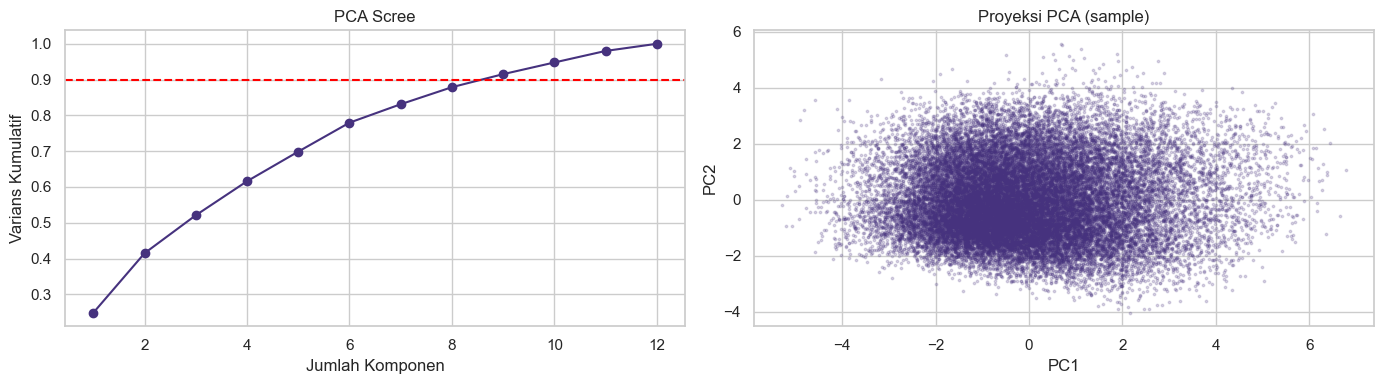

df_pca shape: (2260668, 9)


In [177]:
pca_full = PCA().fit(df_final_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(cum >= 0.90) + 1)
print(f'Komponen untuk >=90% varians: {n_comp} (dari {df_final_scaled.shape[1]})')
print('Varians kumulatif:', np.round(cum[:n_comp], 3).tolist())

pca = PCA(n_components=n_comp, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(df_final_scaled)
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_comp)], index=df_final_scaled.index)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(range(1, len(cum)+1), cum, 'o-'); ax[0].axhline(0.90, color='r', ls='--')
ax[0].set_xlabel('Jumlah Komponen'); ax[0].set_ylabel('Varians Kumulatif'); ax[0].set_title('PCA Scree')
samp = np.random.RandomState(RANDOM_SEED).choice(len(df_pca), min(30000, len(df_pca)), replace=False)
ax[1].scatter(df_pca.iloc[samp,0], df_pca.iloc[samp,1], s=3, alpha=0.2)
ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2'); ax[1].set_title('Proyeksi PCA (sample)')
plt.tight_layout(); plt.show()
print('df_pca shape:', df_pca.shape)

### 4.5: UMAP (Input DBSCAN)

UMAP mempertahankan struktur non-linear lokal, cocok untuk DBSCAN mendeteksi profil outlier. Karena UMAP & DBSCAN mahal pada 2,26 juta baris, keduanya dijalankan pada **sample representatif** (seeded); hasilnya menjadi input DBSCAN di Phase 2.

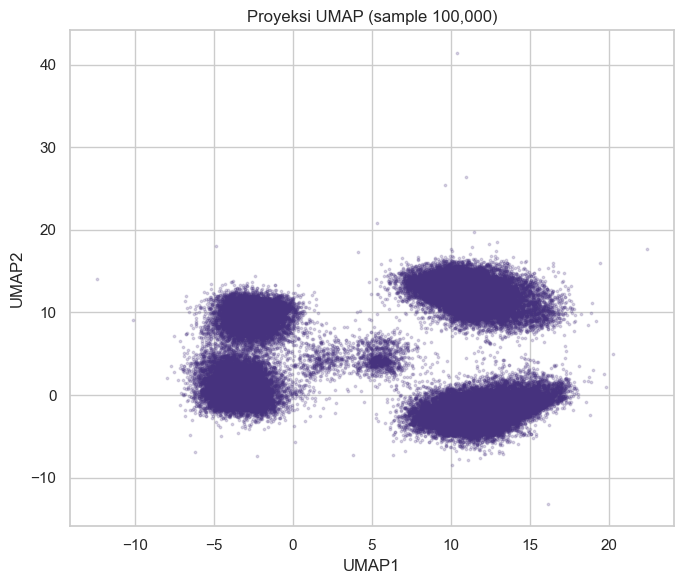

df_umap shape: (100000, 2)


In [178]:
import umap

UMAP_SAMPLE = 100_000
s = min(UMAP_SAMPLE, len(df_final_scaled))
idx = np.random.RandomState(RANDOM_SEED).choice(len(df_final_scaled), s, replace=False)
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    densmap=True, random_state=RANDOM_SEED)  # densMAP: pertahankan densitas
emb = reducer.fit_transform(df_final_scaled.iloc[idx])
df_umap = pd.DataFrame(emb, columns=['UMAP1','UMAP2'], index=df_final_scaled.index[idx])

plt.figure(figsize=(7, 6))
plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], s=3, alpha=0.2)
plt.title(f'Proyeksi UMAP (sample {s:,})'); plt.xlabel('UMAP1'); plt.ylabel('UMAP2')
plt.tight_layout(); plt.show()
print('df_umap shape:', df_umap.shape)

### 4.6: Simpan Output Phase 1

Seluruh artefak Phase 1 diekspor untuk Phase 2–4. Termasuk versi **non-winsorized** (`cleaned_lending_club_no_winsorization.csv`) berisi nilai asli fitur final, khusus untuk Anomaly Detection Phase 4.

In [179]:
outputs = {
    'data/processed/cleaned_lending_club.csv'      : df_final,            # subset final, unscaled (interpretasi profil)
    'data/processed/cleaned_lending_club_no_winsorization.csv': df_prewinsor[final_features],  # Phase 4 anomaly (nilai asli)
    'data/processed/scaled_lending_club.csv'       : df_final_scaled,     # subset final, scaled
    'data/processed/lending_club_pca.csv'          : df_pca,              # input K-Means / Hierarchical
    'data/processed/lending_club_apriori_binned.csv': arm_df,             # input Phase 3 (Apriori)
    'data/processed/loan_status_reference.csv'     : loan_status_ref.to_frame('loan_status'),
}
if len(df_umap):
    outputs['data/processed/lending_club_umap.csv'] = df_umap             # input DBSCAN (sample)

for name, obj in outputs.items():
    obj.to_csv(name, index=False)
    print(f'  tersimpan: {name:34s} {obj.shape}')
print('\nSemua output Phase 1 tersimpan.')

  tersimpan: cleaned_lending_club.csv           (2260668, 12)
  tersimpan: cleaned_lending_club_no_winsorization.csv (2260668, 12)
  tersimpan: scaled_lending_club.csv            (2260668, 12)
  tersimpan: lending_club_pca.csv               (2260668, 9)
  tersimpan: lending_club_apriori_binned.csv    (2260668, 9)
  tersimpan: loan_status_reference.csv          (2260668, 1)
  tersimpan: lending_club_umap.csv              (100000, 2)

Semua output Phase 1 tersimpan.


---
## Step 5: EDA Setelah Preprocessing (Quality Check)

Sebelum masuk clustering, kualitas subset final diverifikasi: (1) distribusi & skewness fitur final setelah transformasi, (2) korelasi antar fitur final (memastikan redundansi sudah rendah), dan (3) PCA loadings untuk memahami makna tiap komponen, bekal interpretasi cluster di Phase 2.

### 5.1: Distribusi & Skewness Fitur Final

Skewness fitur final (unscaled, setelah transform):
total_bc_limit    1.85
bc_open_to_buy   -1.60
fico_range_low    1.01
term              0.94
inq_last_6mths    0.92
loan_amnt         0.78
grade             0.64
dti               0.34
all_util         -0.22
emp_length       -0.21
annual_inc        0.06
revol_util        0.01


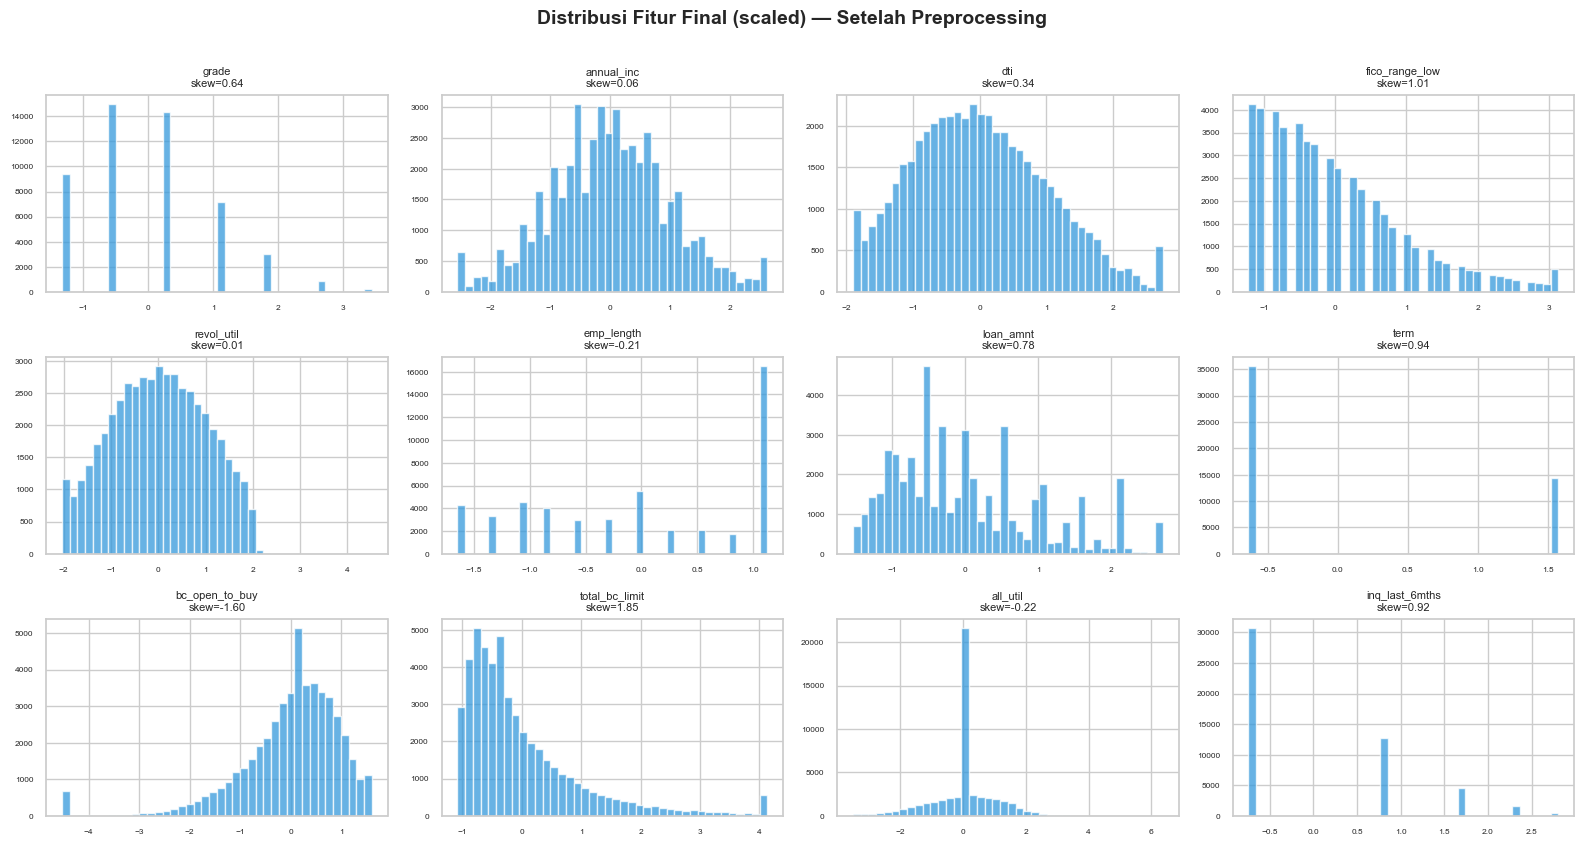

In [180]:
print('Skewness fitur final (unscaled, setelah transform):')
print(df_final.skew().reindex(df_final.skew().abs().sort_values(ascending=False).index).round(2).to_string())

cols = list(df_final_scaled.columns)
ncol = 4; nrow = int(np.ceil(len(cols)/ncol))
samp = np.random.RandomState(RANDOM_SEED).choice(len(df_final_scaled), min(50_000, len(df_final_scaled)), replace=False)
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*4, nrow*2.8)); axes = axes.flatten()
for i, c in enumerate(cols):
    axes[i].hist(df_final_scaled[c].iloc[samp], bins=40, color='#3498db', alpha=0.75, edgecolor='white')
    axes[i].set_title(f'{c}\nskew={df_final[c].skew():.2f}', fontsize=8)
    axes[i].tick_params(labelsize=6)
for j in range(len(cols), len(axes)): axes[j].axis('off')
plt.suptitle('Distribusi Fitur Final (scaled) — Setelah Preprocessing', fontsize=14, fontweight='bold', y=1.004)
plt.tight_layout(); plt.show()

### 5.2: Korelasi Subset Final (Verifikasi Redundansi Rendah)

Setelah pruning, korelasi antar fitur final semestinya rendah. Nilai absolut tertinggi menjadi indikator apakah masih ada redundansi tersisa.

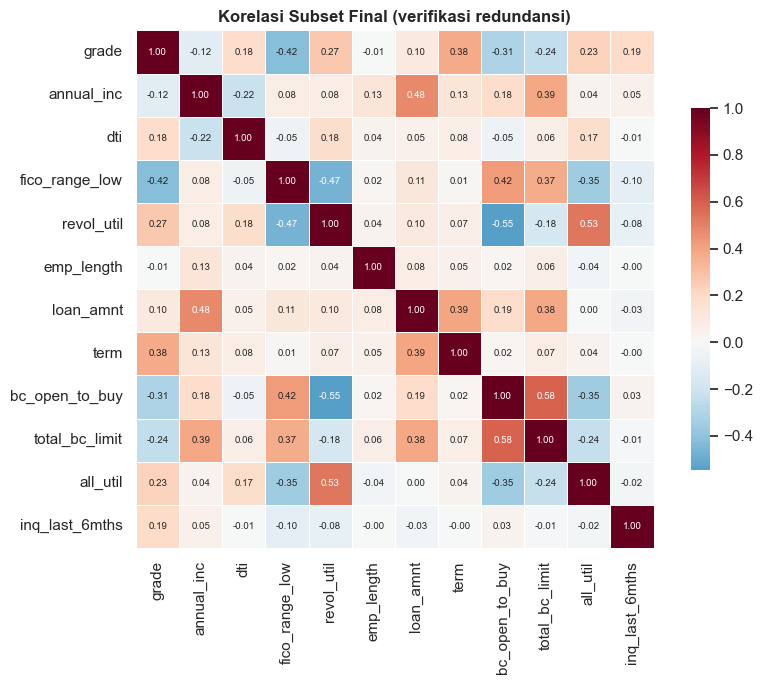

Korelasi absolut tertinggi antar fitur final: 0.58  (baik bila < 0.70)


In [181]:
fig, ax = plt.subplots(figsize=(9, 7))
cf = df_final_scaled.corr()
sns.heatmap(cf, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, annot_kws={'size':7}, cbar_kws={'shrink':0.7}, ax=ax)
ax.set_title('Korelasi Subset Final (verifikasi redundansi)', fontweight='bold')
plt.tight_layout(); plt.show()

mx = cf.abs().where(np.triu(np.ones(cf.shape, bool), 1)).max().max()
print(f'Korelasi absolut tertinggi antar fitur final: {mx:.2f}  (baik bila < 0.70)')

### 5.3: PCA Loadings (Interpretasi Komponen untuk Phase 2)

Loadings menunjukkan fitur asli yang mendorong tiap komponen utama, membantu menamai dimensi cluster secara bisnis nanti.

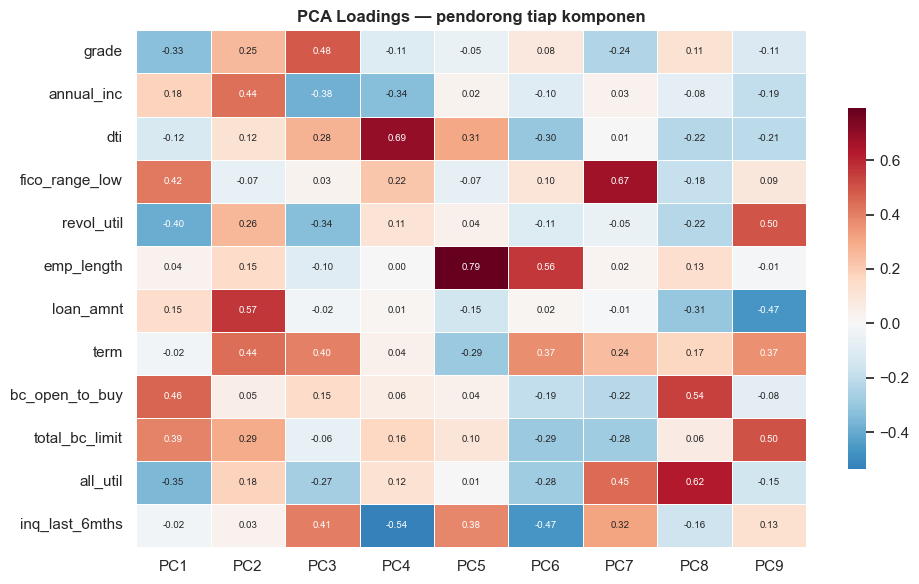

Fitur dominan per komponen:
  PC1: ['bc_open_to_buy', 'fico_range_low', 'revol_util']
  PC2: ['loan_amnt', 'term', 'annual_inc']
  PC3: ['grade', 'inq_last_6mths', 'term']
  PC4: ['dti', 'inq_last_6mths', 'annual_inc']


In [182]:
loadings = pd.DataFrame(pca.components_.T, index=df_final_scaled.columns,
                        columns=[f'PC{i+1}' for i in range(pca.n_components_)])
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, annot_kws={'size':7}, cbar_kws={'shrink':0.7}, ax=ax)
ax.set_title('PCA Loadings — pendorong tiap komponen', fontweight='bold')
plt.tight_layout(); plt.show()

print('Fitur dominan per komponen:')
for pc in loadings.columns[:min(4, loadings.shape[1])]:
    top = loadings[pc].abs().sort_values(ascending=False).head(3).index.tolist()
    print(f'  {pc}: {top}')

---
## Ringkasan Phase 1

### Alur & Hasil (angka aktual dari run penuh 2.260.701 baris)

| Tahap | Aksi | Hasil |
|---|---|---|
| Input | Muat `accepted_2007_to_2018Q4.csv` | 2.260.701 × 151 |
| Cleaning | Drop identifier/teks/konstan/leakage; tangani nulls; hapus duplikat | → **91 fitur**, 0 missing, 33 baris sampah dibuang → 2.260.668 |
| Transformation | Encoding (ordinal+biner, 6 nominal di-drop); winsor **13** fitur; log **52** (8 dibatalkan); quasi-constant buang 5 | → **80 fitur** numerik, scaled |
| Feature selection | Korelasi \|r\|>0,85 buang **16** → 64; MI terhadap `grade`; subset hybrid core+MI (2 ditolak redundan) | → **12 fitur** final |
| Dim. reduction | PCA (≥90% varians) + UMAP 2D (sample 100k) | PCA **9 komponen**; UMAP 100k×2 |
| Quality check (Step 5) | Verifikasi distribusi & redundansi pasca-preprocessing | `dti` skew **0,34**; korelasi maks final **0,58** |

**12 fitur final:** `grade`, `annual_inc`, `dti`, `fico_range_low`, `revol_util`, `emp_length`, `loan_amnt`, `term` (core mining angle) + `bc_open_to_buy`, `total_bc_limit`, `all_util`, `inq_last_6mths` (MI-driven, lolos guard anti-redundan).

**Output tersimpan (7 file):** `cleaned_lending_club.csv` (subset final unscaled), `cleaned_lending_club_no_winsorization.csv` (nilai asli, untuk Anomaly Detection Phase 4), `scaled_lending_club.csv`, `lending_club_pca.csv` (K-Means/Hierarchical), `lending_club_umap.csv` (DBSCAN), `lending_club_apriori_binned.csv` (Phase 3 ARM), `loan_status_reference.csv` (label referensi).

### Justifikasi Parameter & Keputusan (agar tidak ada nilai arbitrer)

| Parameter / keputusan | Nilai | Justifikasi & bukti |
|---|---|---|
| Ambang outlier IQR | 1,5× | Tukey fence standar; hanya untuk pelaporan, bukan penghapusan. |
| Konversi `int_rate`/`revol_util` | strip `%`→float | Nilai numerik yang tersimpan sebagai string, koreksi tipe, bukan pilihan. |
| Sentinel `mths_since_*` | 999 | Satuan bulan; jauh di atas maks teramati (~176) sehingga tak ambigu = "tak pernah". Flag biner `*_present` membawa sinyal utamanya. |
| Imputasi `mort_acc` | grup `total_acc` | `mort_acc` berkorelasi dengan `total_acc`; imputasi berbasis grup lebih akurat dari median global (praktik umum dataset ini). |
| Ambang drop missing | >40% | Rentang lazim literatur (30–50%); dipilih 40% menyeimbangkan retensi vs kualitas. Bukti: hanya `il_util` (47%) + 2 kolom nyaris kosong yang terbuang. |
| Winsorization | 1/99, **data-driven** | Di-cap otomatis untuk fitur kontinu |skew|>1 (bukan daftar hardcode); **guard q99>median** mencegah kolaps zero-inflated. Bukti: `dti` skew mentah 25,9 → 0,34 setelah winsor+log; maks |skew| subset final turun 2,76→1,85. |
| Log transform | \|skew\|>1, **kondisional** | Ambang umum "highly skewed"; log **hanya** diterapkan bila menurunkan \|skew\| (bukti: 8 fitur dibatalkan karena over-correction). |
| Quasi-constant | nilai dominan ≥99% | Fitur mendekati konstan tak punya daya pembeda; penyaringan varians standar. |
| Korelasi multikolinearitas | \|r\|>0,85 | Ambang lazim; tie-break **berbasis prioritas domain** (bukan posisi kolom), target `grade` diproteksi (`assert`). |
| MI | sample 50k, k=5 | 50k representatif & traktabel untuk 2,26 juta baris; k=5 lazim untuk MI kontinu. |
| Guard redundansi subset | \|r\|>0,70 | Menolak fitur MI-tinggi yang redundan (bukti: `bc_util`, `percent_bc_gt_75` ditolak; korelasi maks final 0,58). |
| Ukuran subset | ~12 | Selaras mining angle + interpretabilitas; menghindari overkill fitur bureau. |
| PCA | ≥90% varians | Kriteria retensi varians standar → 9 komponen. |
| UMAP | n_neighbors=15, min_dist=0,1, sample 100k | Default seimbang lokal/global; sampling karena UMAP+DBSCAN mahal pada 2,26 juta baris. |

**Daftar kolom domain** (mis. `post_loan`, `id_text`, `mining_core`, `heavy_tail`) berbasis kamus data Lending Club dan mining angle penugasan, dinamai eksplisit karena memang keputusan domain, bukan angka arbitrer.

### Catatan Etis & Metodologis (untuk Limitations laporan)
- **Fair lending:** proxy geografis (`addr_state`, `zip_code`) dan teks bebas (`emp_title`, `desc`) dibuang; tidak ada atribut terproteksi dipakai. Namun `annual_inc`/`emp_length`/`fico` dapat berkorelasi dengan atribut terproteksi → potensi *disparate impact* wajib dicatat.
- **`grade`** mewarisi keputusan risiko historis LC; interpretasi cluster harus menyadari ini.
- **Validitas:** tidak ada data leakage (kolom post-loan & `loan_status` dipisah); winsorization **tidak** dipakai untuk Phase 4 (disediakan versi non-winsorized).

**Phase 1 selesai.** Lanjut Phase 2 (clustering): `lending_club_pca.csv` untuk K-Means/Hierarchical, `lending_club_umap.csv` untuk DBSCAN, profiling memakai `cleaned_lending_club.csv`.